# Targeted Marketing: Utilizing Machine Learning to Identify High-Value Leads

## Introduction
In today's competitive business environment, understanding and improving sales effectiveness is crucial for sustained growth. Sales teams often rely on large datasets containing information about leads, sales agents, and customer interactions. By analyzing this data, businesses can gain valuable insights into their sales process and optimize their strategies to convert more leads into paying customers.

This project focuses on two primary objectives:
#### 1) Data Exploration for Sales Effectiveness:
The first objective of this project is to perform a comprehensive exploration of the available sales data to uncover insights into the factors that influence sales success. By examining variables such as lead sources, sales agents, delivery modes, and geographic locations, we aim to identify patterns and trends that contribute to higher lead conversion rates.

#### 2) Predictive Modeling for Lead Categorization:
The second goal is to build a machine learning model to predict the Lead Category (High Potential or Low Potential). By analyzing historical data, the model aims to classify leads based on various factors such as lead source, sales agent, location, and lead status. This predictive model will enable the sales team to prioritize high-potential leads, allocate resources more efficiently, and improve overall sales effectiveness.

*This project will not only enhance the organization’s understanding of its sales process but also provide a forward-looking tool to optimize future sales efforts, driving better decision-making and improving overall sales effectiveness.*

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('project_sales.csv', encoding='latin1')

In [3]:
data

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [4]:
data.shape

(7422, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Created        7422 non-null   object 
 1   Product_ID     7364 non-null   float64
 2   Source         7405 non-null   object 
 3   Mobile         5612 non-null   object 
 4   EMAIL          7422 non-null   object 
 5   Sales_Agent    7399 non-null   object 
 6   Location       7364 non-null   object 
 7   Delivery_Mode  7422 non-null   object 
 8   Status         7422 non-null   object 
dtypes: float64(1), object(8)
memory usage: 522.0+ KB


In [6]:
data.isnull().sum()                    #to check any NaN values

Created             0
Product_ID         58
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           58
Delivery_Mode       0
Status              0
dtype: int64

In [7]:
data['Status'].value_counts()             # target,output categories counts

Status
Junk Lead               1536
Not Responding          1129
CONVERTED                834
Just Enquiry             760
Potential                708
Long Term                646
In Progress Positive     643
In Progress Negative     626
LOST                     440
Open                      82
converted                 18
Name: count, dtype: int64

In [8]:
data['Source'].value_counts()

Source
Call                             2547
Live Chat-Direct                 1834
Website                          1594
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Personal Contact                   50
Live Chat-CPC                      50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name: count, dtype: int64

In [9]:
data['Sales_Agent'].value_counts()

Sales_Agent
Sales-Agent-4     1500
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      49
Sales-Agent-1        4
Name: count, dtype: int64

In [10]:
data['Location'].value_counts()

Location
Other Locations    2500
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

In [11]:
data['Delivery_Mode'].value_counts()

Delivery_Mode
Mode-5    2975
Mode-1    2627
Mode-3    1688
Mode-4     121
Mode-2      11
Name: count, dtype: int64

In [12]:
data.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')


                                ** Domain Analysis **
1) Created:- The date and time when the lead or record was created.
2) Product ID:- Identifier for the product being inquired about by the lead. However, it contains mostly missing values in this dataset.
3) Source:- The source from which the lead originated (e.g., Website, Live Chat, Referral).
4) Mobile:- The mobile phone number associated with the lead or customer.
5) EMAIL:- The email address associated with the lead or customer.
6) Sales Agent:- The sales agent handling the lead.
7) Location:- The geographic location of the lead or customer, which could indicate region or area.
8) Delivery Mode:- The mode of delivery for the product or service, which might include physical or digital delivery.
9) Status:- The current status of the lead (e.g., Open, Closed). This indicates the progress of the lead in the sales pipeline.


* The "Created" timestamp will not be directly used in the model, so it will be dropped.
* Even though it has missing values, Product_ID is important as different products might have different conversion rates. This feature could impact lead categorization as customers may behave differently based on the product.
* Different lead sources can have varying conversion rates, so this feature could strongly influence lead categorization as "High Potential" or "Low Potential."
* The specific mobile number itself does not contribute to model building, so it will be dropped.
* Similar to the "Mobile" column, the email address itself is not useful for the model, so it will be dropped.
* The performance of different sales agents can significantly impact lead conversion. This feature helps identify which agents handle high-potential leads more effectively.
* Location may influence lead potential due to varying regional market trends or customer behavior, making it important for model predictions.
* Different delivery modes might have different success rates for closing leads, depending on customer preferences.
* The "Status" column may indicate whether the lead converted and can be used either directly or to derive new features to assess lead progression in the pipeline.

In [13]:
data.drop(['Created','Mobile','EMAIL'],axis=1,inplace=True)

In [14]:
data

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
0,NaN,Website,Sales-Agent-11,NaN,Mode-5,Open
1,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
2,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
3,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
4,NaN,Website,Sales-Agent-10,NaN,Mode-5,Open
...,...,...,...,...,...,...
7417,9.0,Call,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,15.0,Call,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,5.0,Live Chat-Direct,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,21.0,CRM form,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


In [15]:
#Check Isnull and isna - no blanks or nans
print(data.isna().sum(), data.isnull().sum())

Product_ID       58
Source           17
Sales_Agent      23
Location         58
Delivery_Mode     0
Status            0
dtype: int64 Product_ID       58
Source           17
Sales_Agent      23
Location         58
Delivery_Mode     0
Status            0
dtype: int64


## Objective-1: Data Exploration for Sales Effectiveness

Key areas of exploration include:

* Lead Source Performance: Which sources generate the highest volume of leads, and more importantly, which sources yield the highest conversion rates?
* Sales Agent Efficiency: How do different sales agents perform in terms of lead conversion? Are there specific agents who consistently outperform others?
* Impact of Delivery Modes: How do various delivery modes affect the likelihood of successful lead conversion?
* Geographical Insights: Which regions or locations demonstrate higher sales effectiveness? Are there opportunities for targeting untapped high-potential areas?

In [16]:
from collections import Counter

#Check product ID with Status
# Give total no of all the rows for which any of the 4 below columns have nan values 
print(Counter(data[data['Product_ID'].isna()  | data['Source'].isna() |
            data['Sales_Agent'].isna() | data['Location'].isna()].Status))

print("\nTotal rows having nan in its row : ",data[data['Product_ID'].isna()  | data['Source'].isna() |
            data['Sales_Agent'].isna() | data['Location'].isna()].shape[0])

# Looking at the data follwing is the inference
# 1) Most of the records have status as "open","Just Enquiry" and "Not Responding". 
#     They are not an catgory of interest for us, so they can be deleted
# 2) Others are very few so we can safely delete all of them. A total of 94 records will be deleted

Counter({'Open': 63, 'Not Responding': 10, 'Just Enquiry': 9, 'Junk Lead': 4, 'Potential': 3, 'Long Term': 2, 'In Progress Positive': 1, 'In Progress Negative': 1, 'LOST': 1})

Total rows having nan in its row :  94


### Product ID 

In [17]:
# product Ids cannot be estimated and all have to be deleted 58 rows
Counter(data[data['Product_ID'].isna()].Status)

Counter({'Open': 49,
         'Just Enquiry': 3,
         'Junk Lead': 2,
         'Not Responding': 2,
         'In Progress Positive': 1,
         'Long Term': 1})

### Source

In [18]:

# print all categoiries of sources - we see there is a category - "Other"
print("\n",Counter(data.Source))

# get all rows where Source has null - 17 nans
print("\n",Counter(data[data['Source'].isna()].Source))

# study the split of the statuses across these 17 nans
print("\n",Counter(data[data['Source'].isna()].Status))

# Conclusion - instead of deleting we can update all these records to "Other"

# Update Source to Other
data.loc[data['Source'].isna(),['Source']] = 'Other'

## Check Status after the update - 19 in others
print("\n After",Counter(data.Source))




 Counter({'Call': 2547, 'Live Chat-Direct': 1834, 'Website': 1594, 'Live Chat-Google Organic': 274, 'Live Chat -PPC': 249, 'Live Chat-Blog': 237, 'Customer Referral': 180, 'US Website': 137, 'Just Dial': 56, 'Existing Client': 51, 'Live Chat-CPC': 50, 'Personal Contact': 50, 'By Recommendation': 32, 'CRM form': 23, 'Existing Customer': 22, 'Live Chat-Google Ads': 21, 'Campaign': 19, nan: 17, 'E-mail Campaign': 12, 'Live Chat-Adwords Remarketing': 7, 'Live Chat-Quora': 2, 'Other': 2, 'SMS Campaign': 2, 'Live Chat-Youtube': 2, 'E-Mail Message': 1, 'Live Chat-Justdial': 1})

 Counter({nan: 17})

 Counter({'Open': 10, 'Not Responding': 2, 'Just Enquiry': 1, 'Junk Lead': 1, 'In Progress Negative': 1, 'LOST': 1, 'Potential': 1})

 After Counter({'Call': 2547, 'Live Chat-Direct': 1834, 'Website': 1594, 'Live Chat-Google Organic': 274, 'Live Chat -PPC': 249, 'Live Chat-Blog': 237, 'Customer Referral': 180, 'US Website': 137, 'Just Dial': 56, 'Existing Client': 51, 'Live Chat-CPC': 50, 'Person

### Location

In [19]:
# print all categoiries of sources - we see there is a category - "Other"
print("\n",Counter(data.Location))

# get all rows where Source has null - 17 nans
print("\n",Counter(data[data['Location'].isna()].Location))

# study the split of the statuses across these 17 nans
print("\n",Counter(data[data['Location'].isna()].Status))

# Conclusion - instead of deleting we can update all these records to "Other"

# Update Location to Other
data.loc[data['Location'].isna(),['Location']] = 'Other Locations'

## Check Status after the update - 58 in other Location (2558)
print("\n After",Counter(data.Location))


 Counter({'Other Locations': 2500, 'Bangalore': 2084, 'Chennai': 909, 'Hyderabad': 528, 'Delhi': 471, 'Mumbai': 402, 'Pune': 142, 'UAE': 79, nan: 58, 'Trivandrum': 58, 'Kolkata': 55, 'USA': 45, 'UK': 41, 'AUSTRALIA': 25, 'Singapore': 17, 'Malaysia': 4, 'EUROPE': 3, 'Howrah': 1})

 Counter({nan: 58})

 Counter({'Open': 49, 'Not Responding': 4, 'Just Enquiry': 3, 'Long Term': 1, 'Junk Lead': 1})

 After Counter({'Other Locations': 2558, 'Bangalore': 2084, 'Chennai': 909, 'Hyderabad': 528, 'Delhi': 471, 'Mumbai': 402, 'Pune': 142, 'UAE': 79, 'Trivandrum': 58, 'Kolkata': 55, 'USA': 45, 'UK': 41, 'AUSTRALIA': 25, 'Singapore': 17, 'Malaysia': 4, 'EUROPE': 3, 'Howrah': 1})


### Sales_Agent

In [20]:
# print all categoiries of sources - we see there is a category - "Other"
print("\n",Counter(data.Sales_Agent))

# get all rows where Source has null - 17 nans
print("\n",Counter(data[data['Sales_Agent'].isna()].Sales_Agent))

# study the split of the statuses across these 17 nans
print("\n",Counter(data[data['Sales_Agent'].isna()].Status))

# Conclusion - instead of deleting we can update all these records to "Other"

# Update Sales Agent to Other
data.loc[data['Sales_Agent'].isna(),['Sales_Agent']] = 'Sales-Agent-Other'

## Check Status after the update - 23 in Sales-Agent-Other (23)
print("\n After",Counter(data.Sales_Agent))


 Counter({'Sales-Agent-4': 1500, 'Sales-Agent-11': 1420, 'Sales-Agent-5': 1190, 'Sales-Agent-9': 879, 'Sales-Agent-3': 781, 'Sales-Agent-7': 736, 'Sales-Agent-2': 389, 'Sales-Agent-12': 269, 'Sales-Agent-6': 114, 'Sales-Agent-8': 68, 'Sales-Agent-10': 49, nan: 23, 'Sales-Agent-1': 4})

 Counter({nan: 23})

 Counter({'Open': 14, 'Just Enquiry': 4, 'Not Responding': 3, 'Potential': 2})

 After Counter({'Sales-Agent-4': 1500, 'Sales-Agent-11': 1420, 'Sales-Agent-5': 1190, 'Sales-Agent-9': 879, 'Sales-Agent-3': 781, 'Sales-Agent-7': 736, 'Sales-Agent-2': 389, 'Sales-Agent-12': 269, 'Sales-Agent-6': 114, 'Sales-Agent-8': 68, 'Sales-Agent-10': 49, 'Sales-Agent-Other': 23, 'Sales-Agent-1': 4})


In [21]:
# total rows
print("Total rows with NAN in any of their columns",data[data['Product_ID'].isna()  | data['Source'].isna() |
            data['Sales_Agent'].isna() | data['Location'].isna()].shape[0])

print("Split of statuses Counter:",data[data['Product_ID'].isna()].shape[0])

#Check Isnull and isna - no blanks or nans
print(data.isna().sum())

Total rows with NAN in any of their columns 58
Split of statuses Counter: 58
Product_ID       58
Source            0
Sales_Agent       0
Location          0
Delivery_Mode     0
Status            0
dtype: int64


In [22]:
# Delete rows with status as "Just Enquiry" & "Open"
print('before delete of status:',data.shape)
data = data.loc[(data.Status != "Just Enquiry") & (data.Status != "Open"),:]
print('after delete of status:',data.shape) # 842 records were deleted

# 6 rows with Nan in product ID, get deleted
print('before :',data.shape)
data.dropna(inplace=True)
print('after :',data.shape)

# Checks nulls
print(data.isna().sum(), data.isnull().sum())

before delete of status: (7422, 6)
after delete of status: (6580, 6)
before : (6580, 6)
after : (6574, 6)
Product_ID       0
Source           0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64 Product_ID       0
Source           0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6574 entries, 18 to 7421
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     6574 non-null   float64
 1   Source         6574 non-null   object 
 2   Sales_Agent    6574 non-null   object 
 3   Location       6574 non-null   object 
 4   Delivery_Mode  6574 non-null   object 
 5   Status         6574 non-null   object 
dtypes: float64(1), object(5)
memory usage: 359.5+ KB


In [24]:
data

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
18,9.0,Live Chat-Google Organic,Sales-Agent-3,Bangalore,Mode-1,Potential
19,19.0,Call,Sales-Agent-4,Other Locations,Mode-5,Potential
24,18.0,Website,Sales-Agent-11,Trivandrum,Mode-1,Potential
25,15.0,Website,Sales-Agent-7,Hyderabad,Mode-1,Not Responding
26,18.0,Call,Sales-Agent-7,Bangalore,Mode-1,In Progress Positive
...,...,...,...,...,...,...
7416,19.0,Live Chat-Direct,Sales-Agent-9,Other Locations,Mode-3,Junk Lead
7417,9.0,Call,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,15.0,Call,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,5.0,Live Chat-Direct,Sales-Agent-11,Bangalore,Mode-1,Not Responding


In [25]:
data['Product_ID']=data['Product_ID'].astype('int64')           #to sure as an int types to show in plots

In [26]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder           
enc=LabelEncoder()
data.Source=enc.fit_transform(data.Source)
data.Sales_Agent=enc.fit_transform(data.Sales_Agent)
data.Location=enc.fit_transform(data.Location)
data.Delivery_Mode=enc.fit_transform(data.Delivery_Mode)

In [27]:
data.Status.value_counts()

Status
Junk Lead               1534
Not Responding          1127
CONVERTED                834
Potential                708
Long Term                645
In Progress Positive     642
In Progress Negative     626
LOST                     440
converted                 18
Name: count, dtype: int64

In [28]:
#lets convert Status into binary classification probs
# 0 -----> Not Potential   & 1-------> Potential
data.Status[data['Status']=='Junk Lead']=0
data.Status[data['Status']=='Not Responding']=0
data.Status[data['Status']=='CONVERTED']=1
data.Status[data['Status']=='Just Enquiry']=1
data.Status[data['Status']=='Potential']=1
data.Status[data['Status']=='Long Term']=1
data.Status[data['Status']=='In Progress Positive']=1
data.Status[data['Status']=='In Progress Negative']=0
data.Status[data['Status']=='LOST']=0
data.Status[data['Status']=='Open']=1
data.Status[data['Status']=='converted']=1

In [29]:
data.Status=data['Status'].astype('int64')

In [30]:
data.Status.value_counts()

Status
0    3727
1    2847
Name: count, dtype: int64

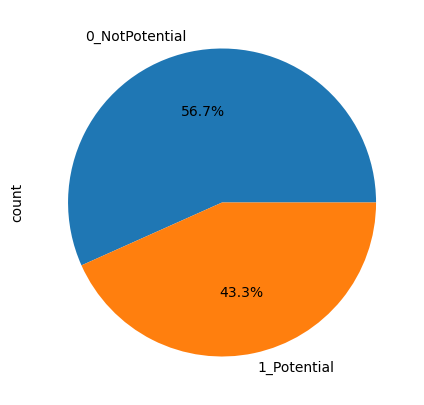

In [31]:
from matplotlib import rcParams

rcParams['figure.figsize'] =10,5
data.Status.value_counts(sort=True).plot.pie(labels=["0_NotPotential",'1_Potential']
                                               ,legend = False, autopct='%1.1f%%',shadow=False)
plt.show()

#### 56.7 % of the leads are not potential leads

In [32]:
data

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
18,9,16,4,1,0,1
19,19,2,5,10,4,1
24,18,23,1,13,0,1
25,15,23,8,6,0,0
26,18,2,8,1,0,1
...,...,...,...,...,...,...
7416,19,14,10,10,2,0
7417,9,2,7,9,3,0
7418,15,2,2,10,4,0
7419,5,14,1,1,0,0


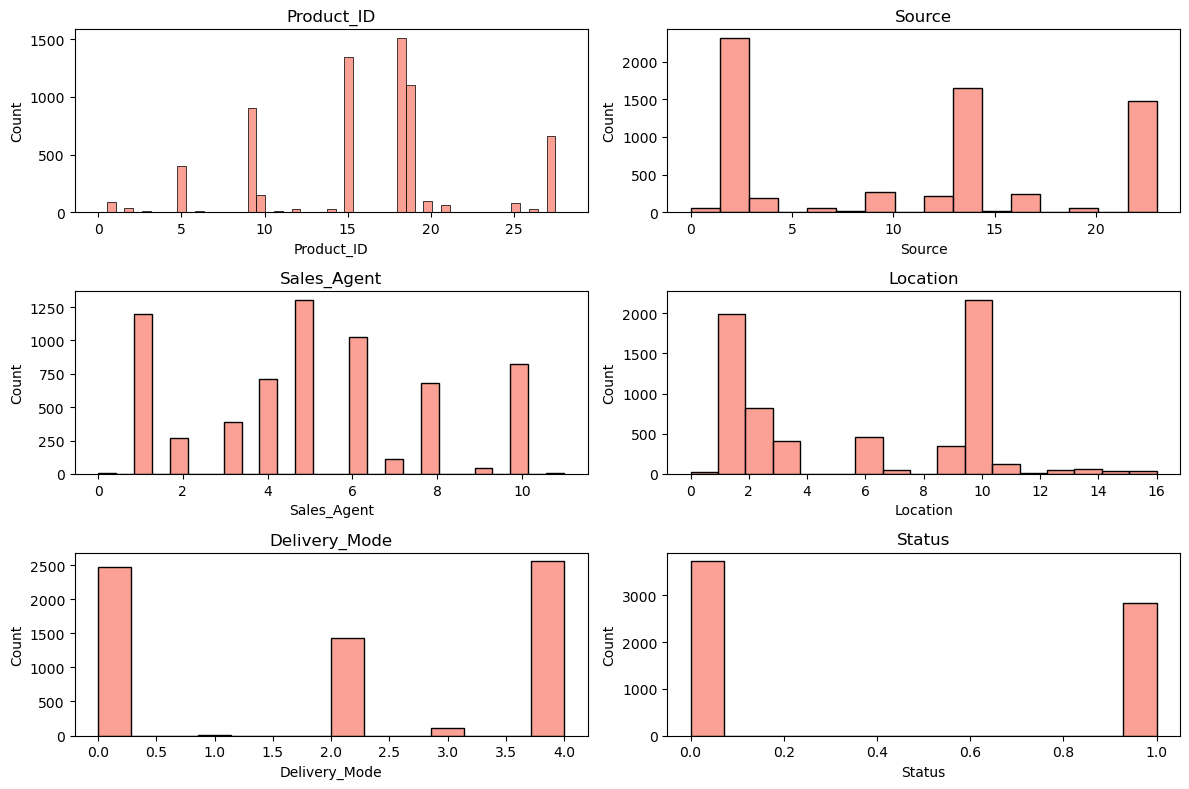

In [33]:
features_to_plot = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']

# Plotting histograms for the selected features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)  # Adjust layout (3 rows, 2 columns)
    sns.histplot(x=feature, data=data, color='salmon')
    plt.title(f"{feature}")
    
plt.tight_layout()
plt.show()

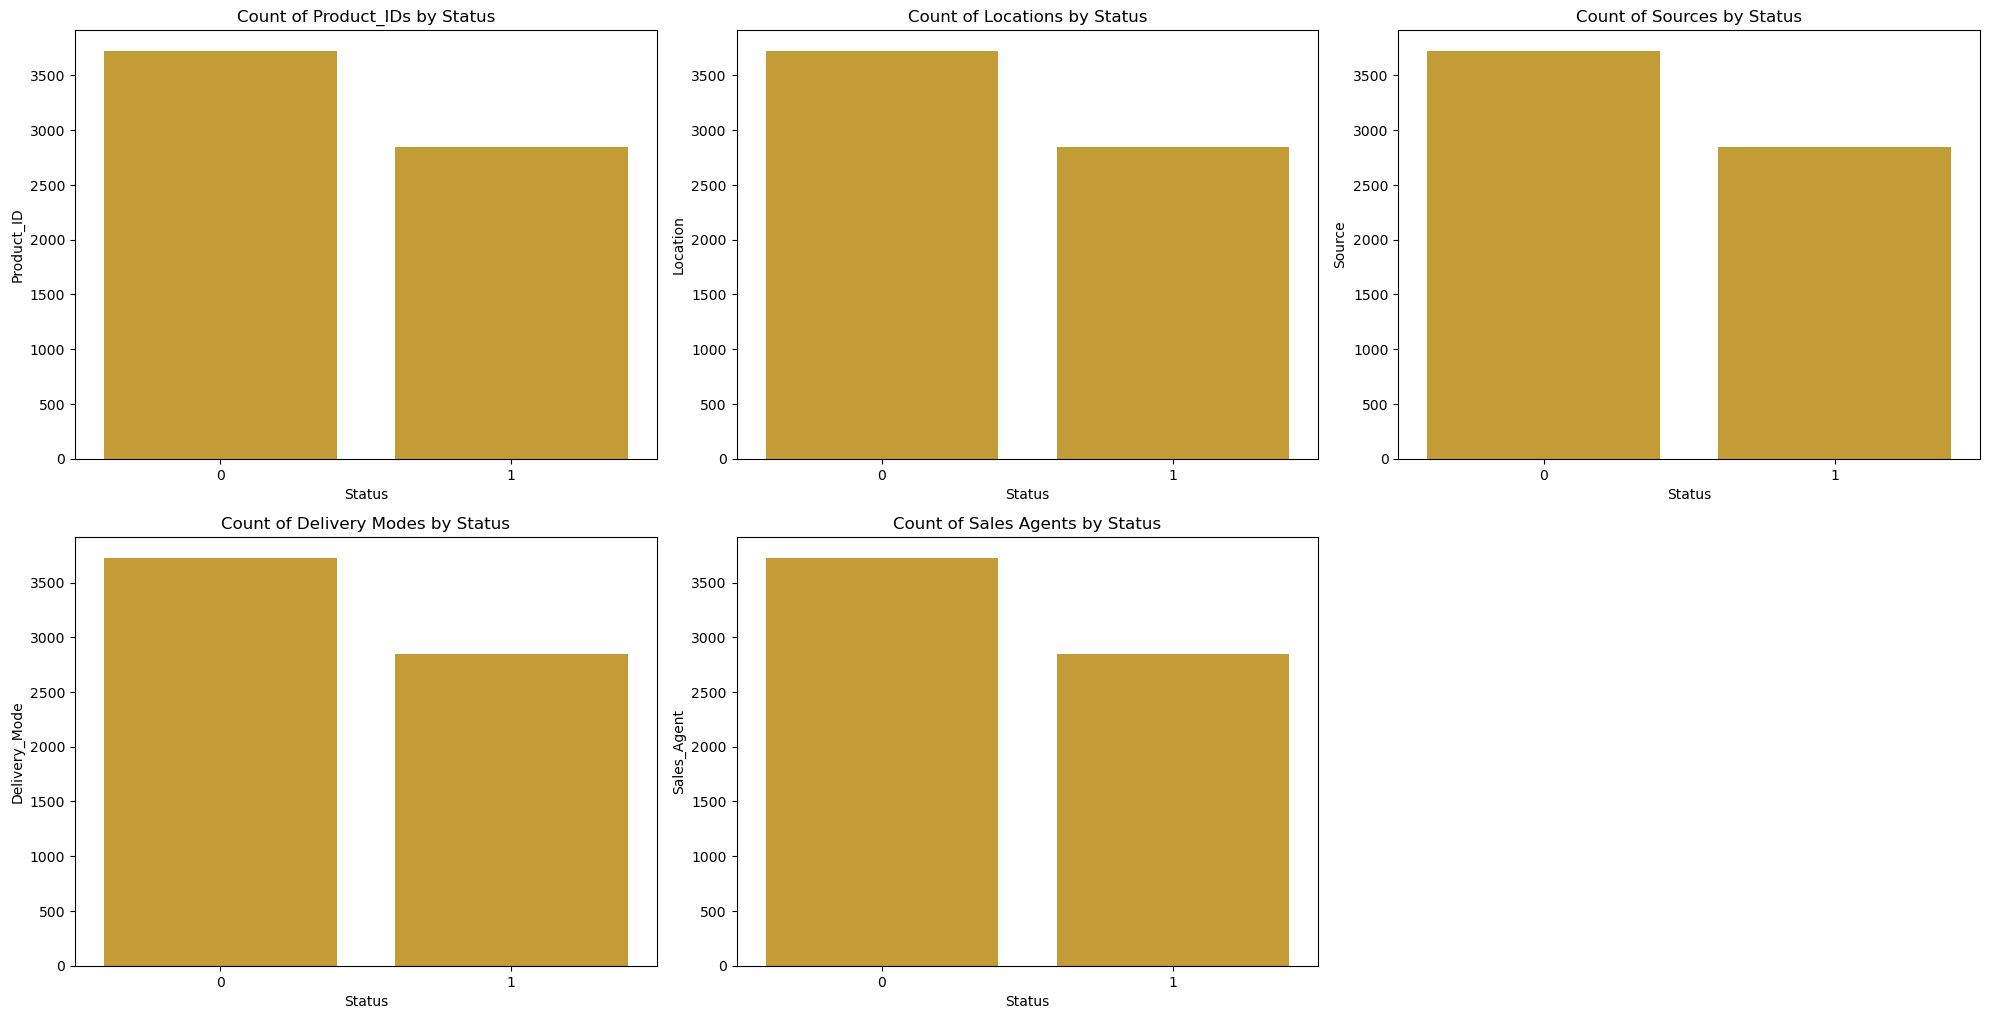

In [34]:
plt.figure(figsize=(20, 20))

# Create bar plots for different categorical features against 'Status'
plt.subplot(4, 3, 1)
sns.barplot(x='Status', y='Product_ID', data=data, estimator=len, color='goldenrod')  # Count of Product_IDs per Status
plt.title('Count of Product_IDs by Status')

plt.subplot(4, 3, 2)
sns.barplot(x='Status', y='Location', data=data, estimator=len, color='goldenrod')  # Count of Locations per Status
plt.title('Count of Locations by Status')

plt.subplot(4, 3, 3)
sns.barplot(x='Status', y='Source', data=data, estimator=len, color='goldenrod')  # Count of Sources per Status
plt.title('Count of Sources by Status')

plt.subplot(4, 3, 4)
sns.barplot(x='Status', y='Delivery_Mode', data=data, estimator=len, color='goldenrod')  # Count of Delivery Modes per Status
plt.title('Count of Delivery Modes by Status')

plt.subplot(4, 3, 5)
sns.barplot(x='Status', y='Sales_Agent', data=data, estimator=len, color='goldenrod')  # Count of Sales Agents per Status
plt.title('Count of Sales Agents by Status')

plt.tight_layout()
plt.show()

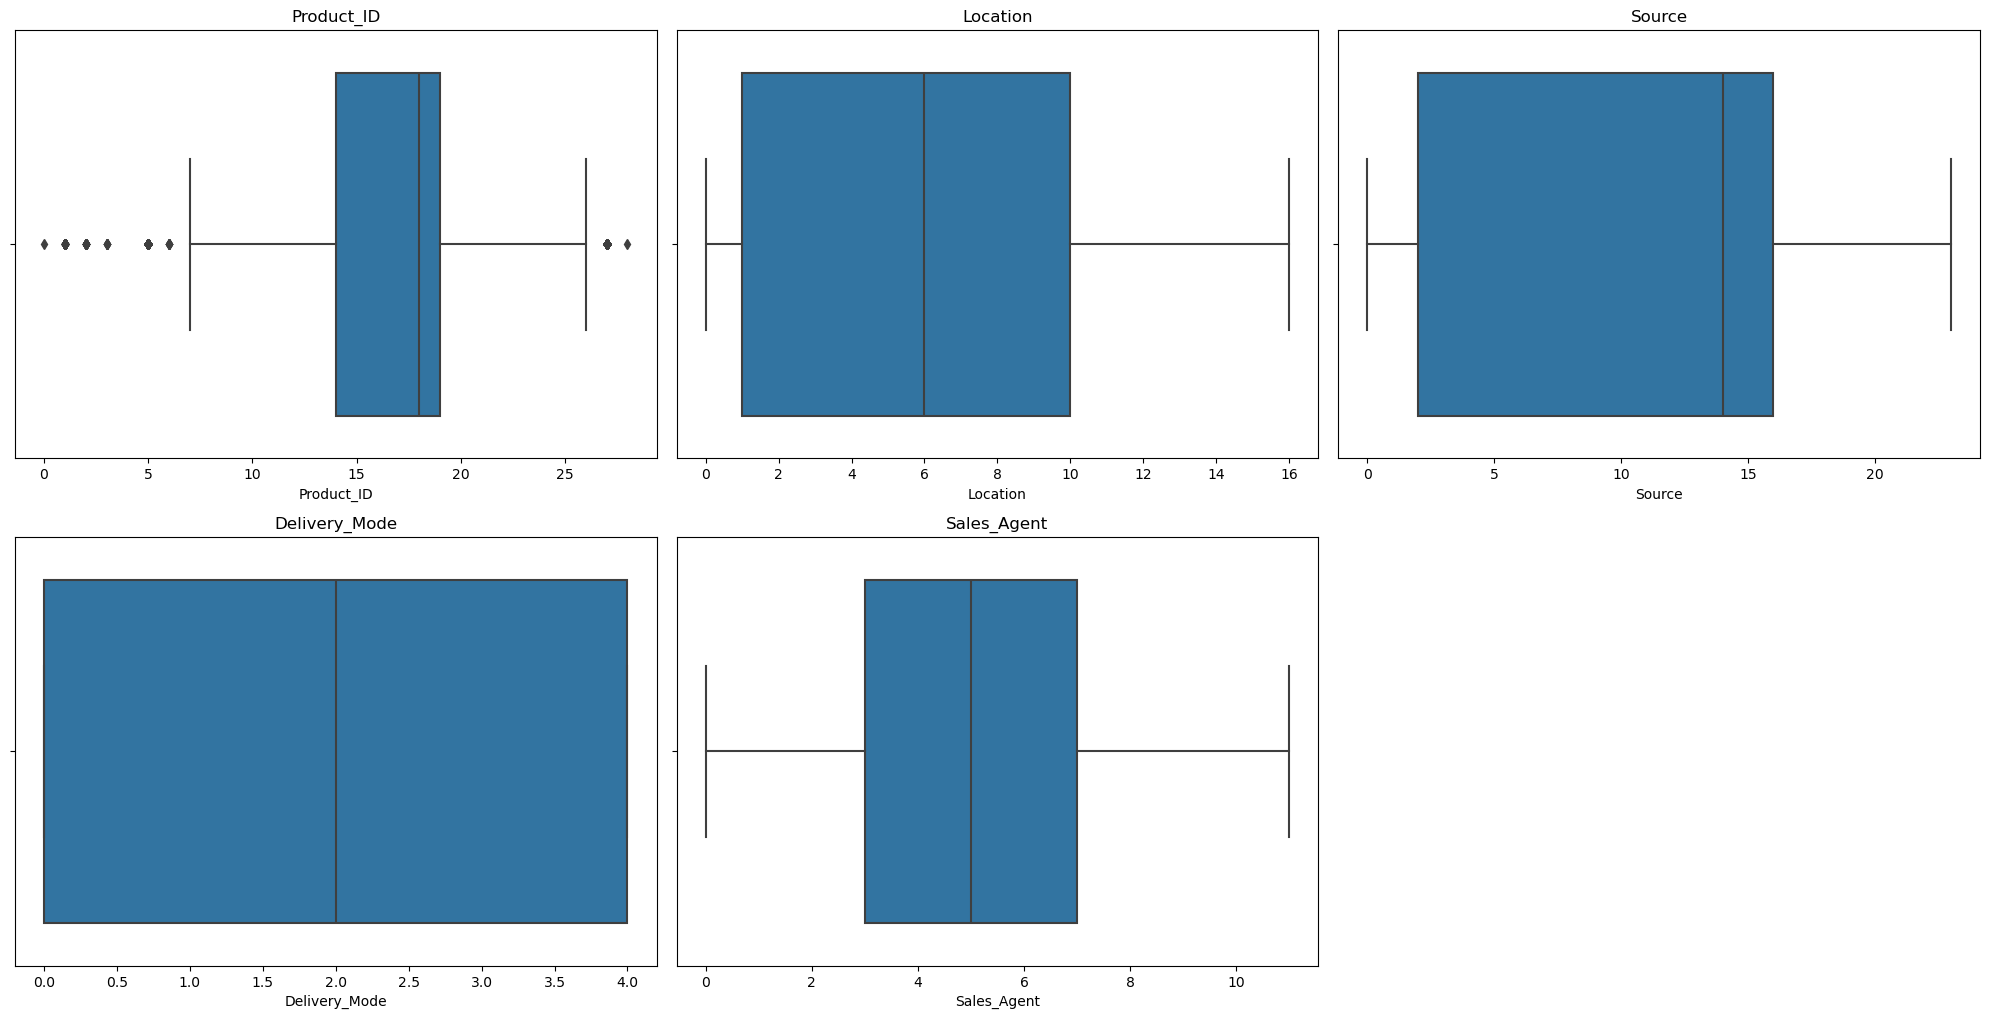

In [35]:
plt.figure(figsize=(20, 20))

plt.subplot(4, 3, 1)
sns.boxplot(x='Product_ID', data=data)
plt.title('Product_ID')

plt.subplot(4, 3, 2)
sns.boxplot(x='Location', data=data)
plt.title('Location')

plt.subplot(4, 3, 3)
sns.boxplot(x='Source', data=data)
plt.title('Source')

plt.subplot(4, 3, 4)
sns.boxplot(x='Delivery_Mode', data=data)
plt.title('Delivery_Mode')

plt.subplot(4, 3, 5)
sns.boxplot(x='Sales_Agent', data=data)
plt.title('Sales_Agent')

# Adjust layout
plt.tight_layout()
plt.show()

### Analysing with Lead Category
#### Using this techinique to analyse each catagorical predictor with outcome variable

#### Analysing Proudct with Lead Category

Status            0        1       All
Product_ID                            
0            0.0152   0.0000    0.0152
1            1.0192   0.2890    1.3082
2            0.3194   0.2130    0.5324
3            0.0456   0.0608    0.1065
5            3.8029   2.3426    6.1454
6            0.0608   0.0456    0.1065
7            0.0152   0.0000    0.0152
8            0.0456   0.0152    0.0608
9            6.2519   7.4840   13.7359
10           0.8366   1.4603    2.2969
11           0.1217   0.0608    0.1825
12           0.2586   0.1825    0.4411
13           0.0456   0.0000    0.0456
14           0.3955   0.0000    0.3955
15          19.2881   1.2169   20.5050
16           0.0456   0.0000    0.0456
17           0.0761   0.0152    0.0913
18          10.2981  12.6863   22.9845
19           6.7843  10.0243   16.8086
20           0.5324   0.9127    1.4451
21           0.4411   0.4716    0.9127
22           0.0608   0.0152    0.0761
23           0.0304   0.0000    0.0304
24           0.0152   0.0

<Axes: title={'center': 'Product ID Vs Lead Quality: Calculated as % Overall records'}, ylabel='Product_ID'>

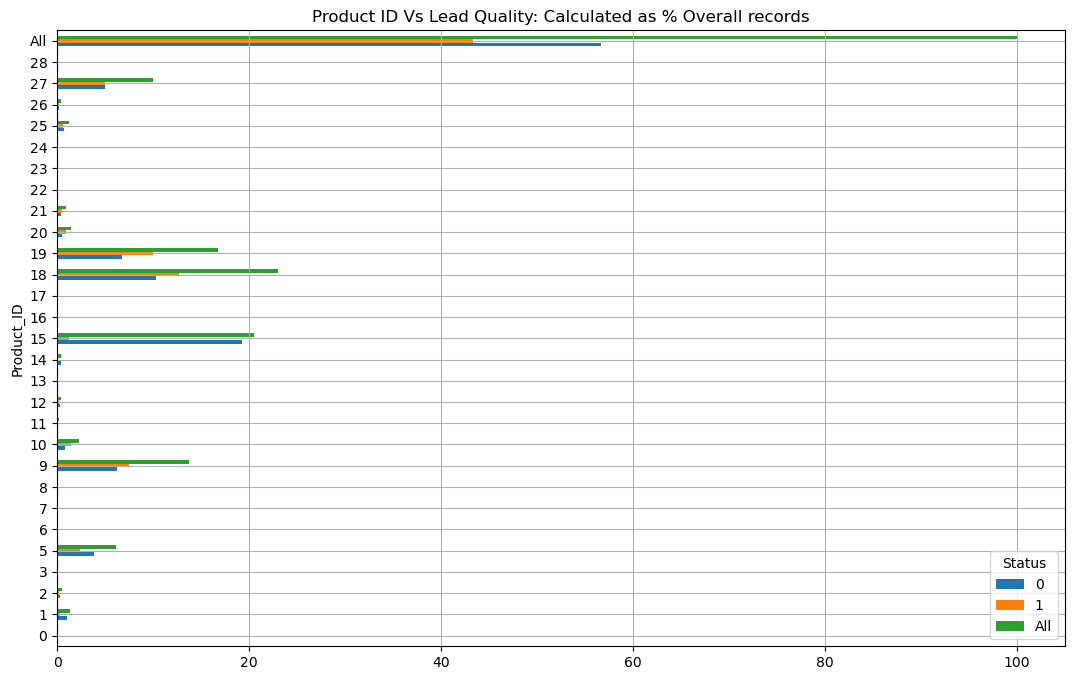

In [36]:
rcParams['figure.figsize'] =13,8
Crosstab_Cat = pd.crosstab([data.Product_ID], data.Status,normalize = 'all',margins=True).round(6)*100
print(Crosstab_Cat)
Crosstab_Cat.plot(kind='barh', stacked=False, grid=True,title="Product ID Vs Lead Quality: Calculated as % Overall records")

* Product Id - 9,15,18,19 are producting highest no. of "not potential" leads
* Product Id - 9,18,19 produce good number of potential leads
* Product Id - 27 produce equal number of potential and not potential leads
* Other products are not generating adquate no of leads

#### Analysing Source with Lead Category

Status        0        1       All
Source                            
0        0.0456   0.4259    0.4716
1        0.2130   0.1065    0.3194
2       21.2352  13.9337   35.1688
3        0.1673   0.1217    0.2890
4        0.2282   2.4490    2.6772
5        0.0000   0.0152    0.0152
6        0.1065   0.0761    0.1825
7        0.0304   0.7301    0.7606
8        0.0304   0.3042    0.3347
9        0.6085   0.2130    0.8214
10       1.7949   1.4451    3.2400
11       0.0608   0.0456    0.1065
12       2.0535   1.1561    3.2096
13       0.4563   0.1825    0.6389
14      13.5534  10.8914   24.4448
15       0.1977   0.0761    0.2738
16       1.8710   1.8254    3.6964
17       0.0152   0.0000    0.0152
18       0.0152   0.0152    0.0304
19       0.0913   0.0304    0.1217
20       0.1521   0.5932    0.7454
21       0.0000   0.0152    0.0152
22       1.5972   0.0304    1.6276
23      12.1692   8.6249   20.7940
All     56.6930  43.3070  100.0000


<Axes: title={'center': 'Sources Vs Lead Quality: Calculated as % Overall records'}, ylabel='Source'>

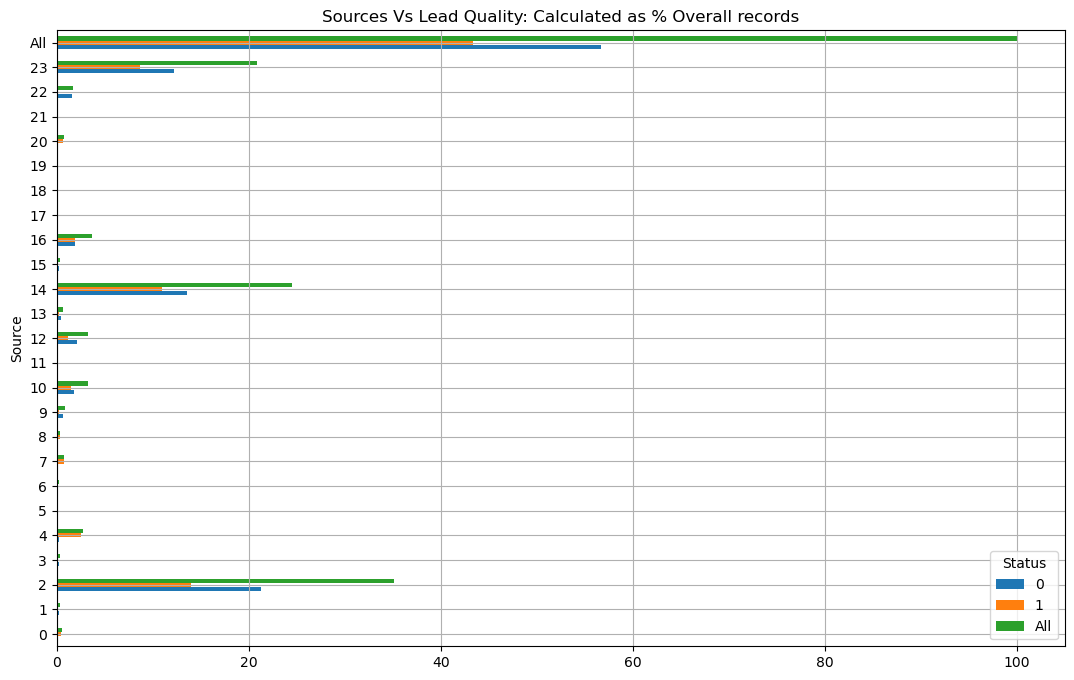

In [37]:
rcParams['figure.figsize'] =13,8
Crosstab_Cat = pd.crosstab([data.Source], data.Status,normalize = 'all',margins=True).round(6)*100
print(Crosstab_Cat)
Crosstab_Cat.plot(kind='barh', stacked=False, grid=True,title="Sources Vs Lead Quality: Calculated as % Overall records")

#### Analysing Sales Agent with Lead Category

Status             0        1       All
Sales_Agent                            
0             0.0761   0.0000    0.0761
1            10.7089   7.5449   18.2537
2             2.8445   1.2473    4.0919
3             3.2705   2.6316    5.9020
4             6.5713   4.2440   10.8153
5            11.5455   8.3054   19.8509
6            10.9066   4.7308   15.6374
7             0.8214   0.9127    1.7341
8             5.5522   4.8524   10.4046
9             0.3042   0.3347    0.6389
10            4.0462   8.4728   12.5190
11            0.0456   0.0304    0.0761
All          56.6930  43.3070  100.0000


<Axes: title={'center': 'Sales Agent Vs Lead Quality: Calculated as % Overall records'}, ylabel='Sales_Agent'>

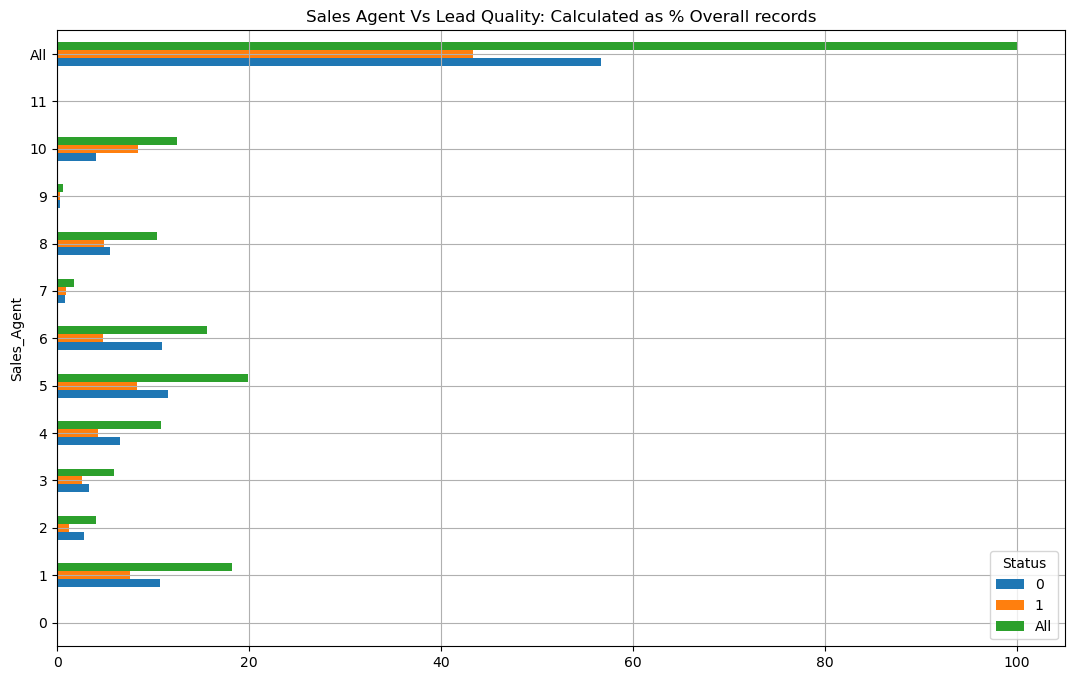

In [38]:
rcParams['figure.figsize'] =13,8
Crosstab_Cat = pd.crosstab([data.Sales_Agent], data.Status,normalize = 'all',margins=True).round(6)*100
print(Crosstab_Cat)
Crosstab_Cat.plot(kind='barh', stacked=False, grid=True,title="Sales Agent Vs Lead Quality: Calculated as % Overall records")

#### Analysing Delivery Mode with Lead Category

Status               0        1       All
Delivery_Mode                            
0              17.2802  20.2464   37.5266
1               0.0304   0.0913    0.1217
2              11.1348  10.5872   21.7219
3               0.5476   1.2321    1.7797
4              27.7000  11.1500   38.8500
All            56.6930  43.3070  100.0000


<Axes: title={'center': 'Delivery Mode Vs Lead Quality: Calculated as % Overall records'}, ylabel='Delivery_Mode'>

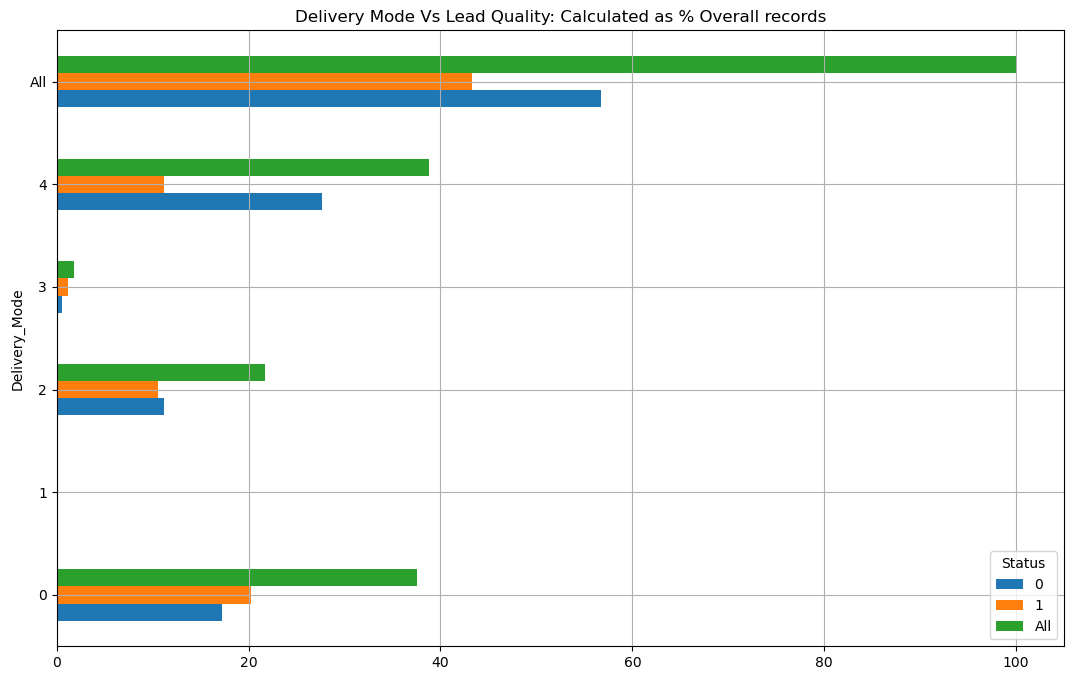

In [39]:
rcParams['figure.figsize'] =13,8
Crosstab_Cat = pd.crosstab([data.Delivery_Mode], data.Status,normalize = 'all',margins=True).round(6)*100
print(Crosstab_Cat)
Crosstab_Cat.plot(kind='barh', stacked=False, grid=True,title="Delivery Mode Vs Lead Quality: Calculated as % Overall records")

* Delivery mode 0 and 2 are best performers
* Mode 4 should be relooked from spending standpoint

#### Analysing Location with Lead Category

Status          0        1       All
Location                            
0          0.1369   0.1521    0.2890
1         10.9218  19.3033   30.2251
2          5.4305   6.9973   12.4277
3          3.6812   2.5099    6.1911
4          0.0000   0.0456    0.0456
5          0.0152   0.0000    0.0152
6          3.8485   3.1336    6.9821
7          0.5020   0.1977    0.6997
8          0.0000   0.0608    0.0608
9          3.0879   2.1296    5.2175
10        26.4679   6.5257   32.9936
11         1.1865   0.6541    1.8406
12         0.0761   0.1369    0.2130
13         0.4107   0.3347    0.7454
14         0.3803   0.5628    0.9431
15         0.2130   0.3042    0.5172
16         0.3347   0.2586    0.5932
All       56.6930  43.3070  100.0000


<Axes: title={'center': 'Location Vs Lead Quality: Calculated as % Overall records'}, ylabel='Location'>

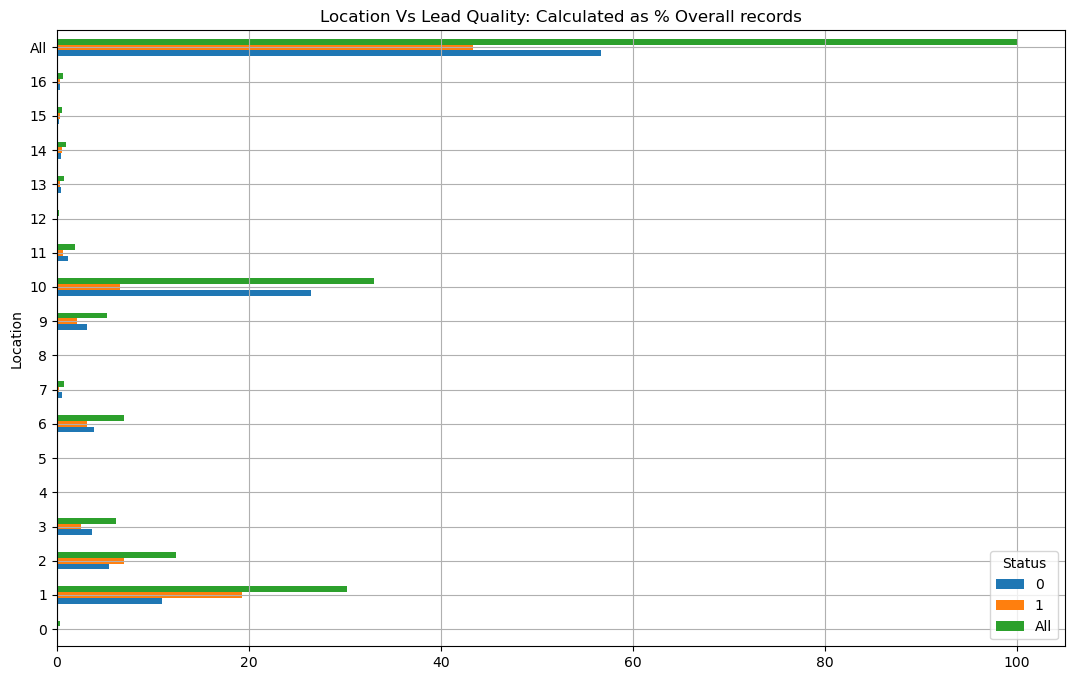

In [40]:
rcParams['figure.figsize'] =13,8
Crosstab_Cat = pd.crosstab([data.Location], data.Status,normalize = 'all',margins=True).round(6)*100
print(Crosstab_Cat)
Crosstab_Cat.plot(kind='barh', stacked=False, grid=True,title="Location Vs Lead Quality: Calculated as % Overall records")

In [41]:
from scipy import stats

# List of categorical columns to test against 'Status'
categorical_columns = ['Product_ID', 'Source', 'Sales_Agent', 'Location', 'Delivery_Mode']

# Iterate through each categorical column and perform Chi-Square test
for col in categorical_columns:
    print(f"Testing {col} with Status...")
    
    # Create a cross-tabulation between the categorical column and the target 'Status'
    contingency_table = pd.crosstab(data[col], data.Status)
    
    # Performing Chi-Square test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    

    print(f"p-value: {p}")
    if p < 0.05:
        print(f"Therefore {col} is IMPORTANT for Prediction (p-value: {p})\n")
    else:
        print(f"Therefore {col} is NOT IMPORTANT for Prediction (p-value: {p})\n")
## p < 0.05: Checks if the p-value is below the significance threshold (0.05). If it is, the variable is considered important for predicting Status.

Testing Product_ID with Status...
p-value: 5.713802972915813e-221
Therefore Product_ID is IMPORTANT for Prediction (p-value: 5.713802972915813e-221)

Testing Source with Status...
p-value: 2.5928905048241263e-73
Therefore Source is IMPORTANT for Prediction (p-value: 2.5928905048241263e-73)

Testing Sales_Agent with Status...
p-value: 1.1340141113532264e-59
Therefore Sales_Agent is IMPORTANT for Prediction (p-value: 1.1340141113532264e-59)

Testing Location with Status...
p-value: 1.22401431768508e-185
Therefore Location is IMPORTANT for Prediction (p-value: 1.22401431768508e-185)

Testing Delivery_Mode with Status...
p-value: 9.495018552662028e-83
Therefore Delivery_Mode is IMPORTANT for Prediction (p-value: 9.495018552662028e-83)



In [42]:
# Define all columns in the dataset
AllColumns = ['Product_ID', 'Source', 'Sales_Agent', 
              'Location', 'Delivery_Mode', 'Status']

# No continuous variables
ConVarList = []

# Categorical variable list (independent variables)
CatVarList = ['Product_ID', 'Source', 'Sales_Agent', 
              'Location', 'Delivery_Mode']

# Outcome variable (dependent variable)
OutcomeVar = ['Status']

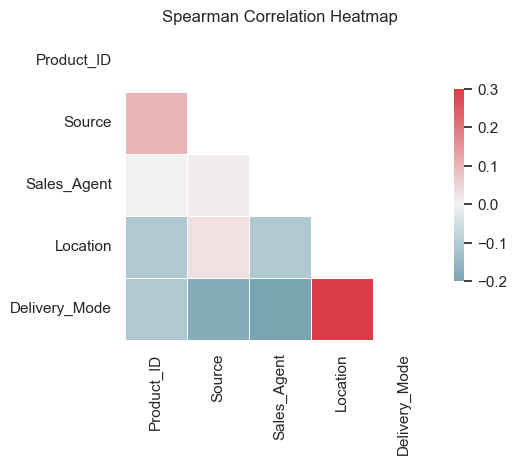

Strong correlations (if any):
                Product_ID  Source  Sales_Agent  Location  Delivery_Mode
Product_ID            1.0     NaN          NaN       NaN            NaN
Source                NaN     1.0          NaN       NaN            NaN
Sales_Agent           NaN     NaN          1.0       NaN            NaN
Location              NaN     NaN          NaN       1.0            NaN
Delivery_Mode         NaN     NaN          NaN       NaN            1.0


In [43]:

# Assuming data is your DataFrame with the categorical variables
Corr_CatVarList = data[CatVarList].corr(method='spearman').round(2)

# Masking the upper triangle
sns.set(style="white")
mask = np.zeros_like(Corr_CatVarList, dtype=bool)  # Use bool instead of np.bool
mask[np.triu_indices_from(mask)] = True

# Plotting
rcParams['figure.figsize'] = 5, 5
sns.heatmap(Corr_CatVarList, annot=True, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
           vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Spearman Correlation Heatmap')
plt.show()

# Check for strong correlations
strong_corr = Corr_CatVarList[(Corr_CatVarList > 0.75) | (Corr_CatVarList < -0.75)]
print("Strong correlations (if any):\n", strong_corr)


## Objective-2: Predictive Modeling for Lead Categorization
Using historical data on leads and their outcomes, we will develop a classification model that can predict the category of a lead based on a variety of factors.

We will employ various machine learning algorithms, such as Logistic Regression, Random Forests, and Gradient Boosting, to build the predictive model. The model will be evaluated based on several performance metrics, including accuracy, precision, recall, and ROC-AUC, ensuring it can effectively distinguish between high-potential and low-potential leads.

## Model Creation and Evaluation

In [44]:
data

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode,Status
18,9,16,4,1,0,1
19,19,2,5,10,4,1
24,18,23,1,13,0,1
25,15,23,8,6,0,0
26,18,2,8,1,0,1
...,...,...,...,...,...,...
7416,19,14,10,10,2,0
7417,9,2,7,9,3,0
7418,15,2,2,10,4,0
7419,5,14,1,1,0,0


In [45]:
x=data.iloc[:,:-1]
y=data.Status

In [46]:
x.head(3)

,Product_ID,Source,Sales_Agent,Location,Delivery_Mode
18,9,16,4,1,0
19,19,2,5,10,4
24,18,23,1,13,0


In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, random_state=42)

In [48]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

In [49]:
## Balacing the data
from imblearn.over_sampling import SMOTE #for balancing the data
sm=SMOTE()#object creation
print(Counter(y_train))# checking count for each class
x_sm,y_sm=sm.fit_resample(x_train_sc,y_train) #applying sampling on target variable
print(Counter(y_sm)) # checking count after sampling for  each class

Counter({0: 2635, 1: 1966})
Counter({1: 2635, 0: 2635})


### LogisticRegression

In [50]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(random_state=42)
LR.fit(x_sm,y_sm)
y_predict=LR.predict(x_test_sc)
y_pre_train=LR.predict(x_sm)

In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,classification_report

In [52]:
acc_lr=accuracy_score(y_test,y_predict)
recall_lr=recall_score(y_test,y_predict,pos_label=1)
prec_lr=precision_score(y_test,y_predict,pos_label=1)
f1_lr=f1_score(y_test,y_predict,pos_label=1)
cl_lr=classification_report(y_test,y_predict)
cm_lr=confusion_matrix(y_test,y_predict)

print(f"Logistic Regression TEST score :")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
pd.crosstab(y_test,y_predict)

Logistic Regression TEST score :
Logistic Regression Accuracy score:0.6644703497212366
Logistic Regression Recall score:0.6912599318955732
Logistic Regression Precision score:0.6096096096096096
Logistic Regression  F1 score:0.6478723404255319
              precision    recall  f1-score   support

           0       0.72      0.64      0.68      1092
           1       0.61      0.69      0.65       881

    accuracy                           0.66      1973
   macro avg       0.67      0.67      0.66      1973
weighted avg       0.67      0.66      0.67      1973

Logistic Regression Confusion Matrix:[[702 390]
 [272 609]]


col_0,0,1
Status,,
0,702,390
1,272,609


In [53]:
acc_lr=accuracy_score(y_sm,y_pre_train)
recall_lr=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lr=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lr=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lr=classification_report(y_sm,y_pre_train)
cm_lr=confusion_matrix(y_sm,y_pre_train)

print(f"Logistic Regression TRAIN score:")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
pd.crosstab(y_sm,y_pre_train)

Logistic Regression TRAIN score:
Logistic Regression Accuracy score:0.6614800759013283
Logistic Regression Recall score:0.6724857685009488
Logistic Regression Precision score:0.6580022279985147
Logistic Regression  F1 score:0.6651651651651652
              precision    recall  f1-score   support

           0       0.67      0.65      0.66      2635
           1       0.66      0.67      0.67      2635

    accuracy                           0.66      5270
   macro avg       0.66      0.66      0.66      5270
weighted avg       0.66      0.66      0.66      5270

Logistic Regression Confusion Matrix:[[1714  921]
 [ 863 1772]]


col_0,0,1
Status,,
0,1714,921
1,863,1772


In [54]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(LR, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
best_params = grid_search.best_params_#it will give you best parameters
print("Best parameters: {}".format(best_params))

Best parameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


In [55]:
Bestparamters: ({'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'})

In [56]:
LR1=LogisticRegression(C=0.01,max_iter=100,penalty='l1',solver='liblinear')

In [57]:
LR1.fit(x_sm,y_sm)
y_predict=LR1.predict(x_test_sc)
y_pre_train=LR1.predict(x_sm)

In [58]:
acc_lr=accuracy_score(y_test,y_predict)
recall_lr=recall_score(y_test,y_predict,pos_label=1)
prec_lr=precision_score(y_test,y_predict,pos_label=1)
f1_lr=f1_score(y_test,y_predict,pos_label=1)
cl_lr=classification_report(y_test,y_predict)
cm_lr=confusion_matrix(y_test,y_predict)

print(f"Logistic Regression TEST score after hyperparameter tuning:")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
pd.crosstab(y_test,y_predict)

Logistic Regression TEST score after hyperparameter tuning:
Logistic Regression Accuracy score:0.659908768373036
Logistic Regression Recall score:0.7150964812712827
Logistic Regression Precision score:0.6
Logistic Regression  F1 score:0.6525116519937856
              precision    recall  f1-score   support

           0       0.73      0.62      0.67      1092
           1       0.60      0.72      0.65       881

    accuracy                           0.66      1973
   macro avg       0.66      0.67      0.66      1973
weighted avg       0.67      0.66      0.66      1973

Logistic Regression Confusion Matrix:[[672 420]
 [251 630]]


col_0,0,1
Status,,
0,672,420
1,251,630


In [59]:
acc_lr=accuracy_score(y_sm,y_pre_train)
recall_lr=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lr=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lr=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lr=classification_report(y_sm,y_pre_train)
cm_lr=confusion_matrix(y_sm,y_pre_train)

print(f"Logistic Regression TRAIN score after hyperparameter tuning:")
print(f"Logistic Regression Accuracy score:{acc_lr}")
print(f"Logistic Regression Recall score:{recall_lr}")
print(f"Logistic Regression Precision score:{prec_lr}")
print(f"Logistic Regression  F1 score:{f1_lr}")
print(f"{cl_lr}")
print(f"Logistic Regression Confusion Matrix:{cm_lr}")
pd.crosstab(y_sm,y_pre_train)

Logistic Regression TRAIN score after hyperparameter tuning:
Logistic Regression Accuracy score:0.6641366223908919
Logistic Regression Recall score:0.7039848197343453
Logistic Regression Precision score:0.6520210896309314
Logistic Regression  F1 score:0.677007299270073
              precision    recall  f1-score   support

           0       0.68      0.62      0.65      2635
           1       0.65      0.70      0.68      2635

    accuracy                           0.66      5270
   macro avg       0.67      0.66      0.66      5270
weighted avg       0.67      0.66      0.66      5270

Logistic Regression Confusion Matrix:[[1645  990]
 [ 780 1855]]


col_0,0,1
Status,,
0,1645,990
1,780,1855


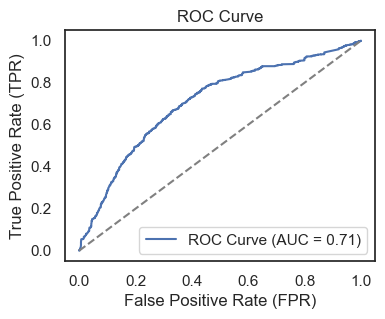

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score

LR2 = LogisticRegression(random_state=42)
LR2.fit(x_train_sc, y_train)  

y_prob = LR2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### DecisionTreeClassifier

In [61]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(x_sm,y_sm)
y_predict=DT.predict(x_test_sc)
y_pre_train=DT.predict(x_sm)

In [62]:
acc_dt=accuracy_score(y_test,y_predict)
recall_dt=recall_score(y_test,y_predict,pos_label=1)
prec_dt=precision_score(y_test,y_predict,pos_label=1)
f1_dt=f1_score(y_test,y_predict,pos_label=1)
cl_dt=classification_report(y_test,y_predict)
cm_dt=confusion_matrix(y_test,y_predict)

print(f"Decision Tree TEST score:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
pd.crosstab(y_test,y_predict)

Decision Tree TEST score:
Decision Tree Accuracy score:0.6659908768373036
Decision Tree Recall score:0.5879682179341658
Decision Tree Precision score:0.6363636363636364
Decision Tree F1 score:0.6112094395280236
              precision    recall  f1-score   support

           0       0.69      0.73      0.71      1092
           1       0.64      0.59      0.61       881

    accuracy                           0.67      1973
   macro avg       0.66      0.66      0.66      1973
weighted avg       0.66      0.67      0.66      1973

Decision Tree Confusion Matrix:[[796 296]
 [363 518]]


col_0,0,1
Status,,
0,796,296
1,363,518


In [63]:
acc_dt=accuracy_score(y_sm,y_pre_train)
recall_dt=recall_score(y_sm,y_pre_train,pos_label=1)
prec_dt=precision_score(y_sm,y_pre_train,pos_label=1)
f1_dt=f1_score(y_sm,y_pre_train,pos_label=1)
cl_dt=classification_report(y_sm,y_pre_train)
cm_dt=confusion_matrix(y_sm,y_pre_train)

print(f"Decision Tree TRAIN score:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
pd.crosstab(y_sm,y_pre_train)

Decision Tree TRAIN score:
Decision Tree Accuracy score:0.8850094876660342
Decision Tree Recall score:0.8535104364326376
Decision Tree Precision score:0.9108950992304576
Decision Tree F1 score:0.8812695924764891
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      2635
           1       0.91      0.85      0.88      2635

    accuracy                           0.89      5270
   macro avg       0.89      0.89      0.88      5270
weighted avg       0.89      0.89      0.88      5270

Decision Tree Confusion Matrix:[[2415  220]
 [ 386 2249]]


col_0,0,1
Status,,
0,2415,220
1,386,2249


In [64]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "criterion": ["gini", "entropy"],  # quality of split
    "splitter": ["best", "random"],    # feature search strategy
    "max_depth": [None, 5, 10, 15],    # maximum depth of tree
    "min_samples_split": np.arange(2, 20),  # samples needed to split internal node
    "min_samples_leaf": np.arange(1, 20),   # samples required at leaf node
    "max_features": [None, "auto", "sqrt", "log2"],  # maximum features considered for split
    "max_leaf_nodes": [None, 10, 20, 30],   # maximum number of leaf nodes
}

tree_clf = DecisionTreeClassifier(random_state=42)
tree_cv = RandomizedSearchCV(tree_clf, param_distributions=params,n_iter=50, scoring='accuracy', n_jobs=-1,cv=5,random_state=42)

tree_cv.fit(x_train,y_train)
best_params = tree_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'splitter': 'best', 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 15, 'criterion': 'entropy'})


In [65]:
Bestparamters: ({'splitter': 'best', 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_leaf_nodes': None, 'max_features': None, 'max_depth': 15, 'criterion': 'entropy'})

In [66]:
DT1=DecisionTreeClassifier(splitter='best',min_samples_split=18,min_samples_leaf=6, max_leaf_nodes=None, max_features=None,max_depth=15, criterion='entropy')

In [67]:
DT1.fit(x_sm,y_sm)
y_predict=DT1.predict(x_test_sc)
y_pre_train=DT1.predict(x_sm)

In [68]:
acc_dt=accuracy_score(y_test,y_predict)
recall_dt=recall_score(y_test,y_predict,pos_label=1)
prec_dt=precision_score(y_test,y_predict,pos_label=1)
f1_dt=f1_score(y_test,y_predict,pos_label=1)
cl_dt=classification_report(y_test,y_predict)
cm_dt=confusion_matrix(y_test,y_predict)

print(f"Decision Tree TEST score after hyperparameter tuning:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
pd.crosstab(y_test,y_predict)

Decision Tree TEST score after hyperparameter tuning:
Decision Tree Accuracy score:0.6705524581855044
Decision Tree Recall score:0.6140749148694665
Decision Tree Precision score:0.63572267920094
Decision Tree F1 score:0.6247113163972287
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      1092
           1       0.64      0.61      0.62       881

    accuracy                           0.67      1973
   macro avg       0.67      0.67      0.67      1973
weighted avg       0.67      0.67      0.67      1973

Decision Tree Confusion Matrix:[[782 310]
 [340 541]]


col_0,0,1
Status,,
0,782,310
1,340,541


In [69]:
acc_dt=accuracy_score(y_sm,y_pre_train)
recall_dt=recall_score(y_sm,y_pre_train,pos_label=1)
prec_dt=precision_score(y_sm,y_pre_train,pos_label=1)
f1_dt=f1_score(y_sm,y_pre_train,pos_label=1)
cl_dt=classification_report(y_sm,y_pre_train)
cm_dt=confusion_matrix(y_sm,y_pre_train)

print(f"Decision Tree TRAIN score after hyperparameter tuning:")
print(f"Decision Tree Accuracy score:{acc_dt}")
print(f"Decision Tree Recall score:{recall_dt}")
print(f"Decision Tree Precision score:{prec_dt}")
print(f"Decision Tree F1 score:{f1_dt}")
print(f"{cl_dt}")
print(f"Decision Tree Confusion Matrix:{cm_dt}")
pd.crosstab(y_sm,y_pre_train)

Decision Tree TRAIN score after hyperparameter tuning:
Decision Tree Accuracy score:0.7967741935483871
Decision Tree Recall score:0.7886148007590132
Decision Tree Precision score:0.8016975308641975
Decision Tree F1 score:0.7951023531662521
              precision    recall  f1-score   support

           0       0.79      0.80      0.80      2635
           1       0.80      0.79      0.80      2635

    accuracy                           0.80      5270
   macro avg       0.80      0.80      0.80      5270
weighted avg       0.80      0.80      0.80      5270

Decision Tree Confusion Matrix:[[2121  514]
 [ 557 2078]]


col_0,0,1
Status,,
0,2121,514
1,557,2078


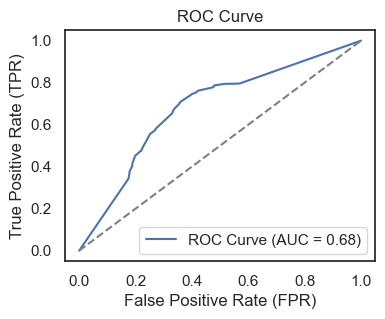

In [70]:

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(x_train_sc, y_train)  

y_prob = tree_clf.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### RandomForestClassifier

In [71]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier(n_estimators=100,random_state=42)
RF.fit(x_sm,y_sm)
y_predict=RF.predict(x_test_sc)
y_pre_train=RF.predict(x_sm)

In [72]:
acc_rf=accuracy_score(y_test,y_predict)
recall_rf=recall_score(y_test,y_predict,pos_label=1)
prec_rf=precision_score(y_test,y_predict,pos_label=1)
f1_rf=f1_score(y_test,y_predict,pos_label=1)
cl_rf=classification_report(y_test,y_predict)
cm_rf=confusion_matrix(y_test,y_predict)

print(f"Random Forest TEST score:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
pd.crosstab(y_test,y_predict)

Random Forest TEST score:
Random Forest Accuracy score:0.6908261530663964
Random Forest Recall score:0.6606129398410897
Random Forest Precision score:0.6517357222844344
Random Forest F1 score:0.6561443066516347
              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1092
           1       0.65      0.66      0.66       881

    accuracy                           0.69      1973
   macro avg       0.69      0.69      0.69      1973
weighted avg       0.69      0.69      0.69      1973

Random Forest Confusion Matrix:[[781 311]
 [299 582]]


col_0,0,1
Status,,
0,781,311
1,299,582


In [73]:
acc_rf=accuracy_score(y_sm,y_pre_train)
recall_rf=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rf=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rf=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rf=classification_report(y_sm,y_pre_train)
cm_rf=confusion_matrix(y_sm,y_pre_train)

print(f"Random Forest TRAIN score:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
pd.crosstab(y_sm,y_pre_train)

Random Forest TRAIN score:
Random Forest Accuracy score:0.8850094876660342
Random Forest Recall score:0.8876660341555977
Random Forest Precision score:0.8829747074367686
Random Forest F1 score:0.8853141559424679
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      2635
           1       0.88      0.89      0.89      2635

    accuracy                           0.89      5270
   macro avg       0.89      0.89      0.89      5270
weighted avg       0.89      0.89      0.89      5270

Random Forest Confusion Matrix:[[2325  310]
 [ 296 2339]]


col_0,0,1
Status,,
0,2325,310
1,296,2339


In [74]:
from skopt import BayesSearchCV

params = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

forest_clf = RandomForestClassifier(random_state=42)
forest_cv = BayesSearchCV(forest_clf, params, n_iter=32, random_state=42, cv=5, scoring='accuracy', n_jobs=-1)

forest_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = forest_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: OrderedDict([('bootstrap', True), ('max_depth', 10), ('max_features', 'sqrt'), ('min_samples_leaf', 4), ('min_samples_split', 10), ('n_estimators', 200)]))


In [75]:
Bestparamters: (([('bootstrap', True), ('max_depth', 10), ('max_features', 'sqrt'), ('min_samples_leaf', 4), ('min_samples_split', 10), ('n_estimators', 200)]))


In [76]:
RF1=RandomForestClassifier(bootstrap=True,max_depth=10,max_features='sqrt',min_samples_leaf=4,min_samples_split=10,n_estimators=200)

In [77]:
RF1.fit(x_sm,y_sm)
y_predict=RF1.predict(x_test_sc)
y_pre_train=RF1.predict(x_sm)

In [78]:
acc_rf=accuracy_score(y_test,y_predict)
recall_rf=recall_score(y_test,y_predict,pos_label=1)
prec_rf=precision_score(y_test,y_predict,pos_label=1)
f1_rf=f1_score(y_test,y_predict,pos_label=1)
cl_rf=classification_report(y_test,y_predict)
cm_rf=confusion_matrix(y_test,y_predict)

print(f"Random Forest TEST score after HP Tuning:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
pd.crosstab(y_test,y_predict)

Random Forest TEST score after HP Tuning:
Random Forest Accuracy score:0.7034972123669538
Random Forest Recall score:0.7412031782065834
Random Forest Precision score:0.6465346534653466
Random Forest F1 score:0.6906398730830249
              precision    recall  f1-score   support

           0       0.76      0.67      0.72      1092
           1       0.65      0.74      0.69       881

    accuracy                           0.70      1973
   macro avg       0.70      0.71      0.70      1973
weighted avg       0.71      0.70      0.70      1973

Random Forest Confusion Matrix:[[735 357]
 [228 653]]


col_0,0,1
Status,,
0,735,357
1,228,653


In [79]:
acc_rf=accuracy_score(y_sm,y_pre_train)
recall_rf=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rf=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rf=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rf=classification_report(y_sm,y_pre_train)
cm_rf=confusion_matrix(y_sm,y_pre_train)

print(f"Random Forest TRAIN score after HP Tuning:")
print(f"Random Forest Accuracy score:{acc_rf}")
print(f"Random Forest Recall score:{recall_rf}")
print(f"Random Forest Precision score:{prec_rf}")
print(f"Random Forest F1 score:{f1_rf}")
print(f"{cl_rf}")
print(f"Random Forest Confusion Matrix:{cm_rf}")
pd.crosstab(y_sm,y_pre_train)

Random Forest TRAIN score after HP Tuning:
Random Forest Accuracy score:0.7992409867172675
Random Forest Recall score:0.8603415559772296
Random Forest Precision score:0.7666553939803855
Random Forest F1 score:0.8108011444921316
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      2635
           1       0.77      0.86      0.81      2635

    accuracy                           0.80      5270
   macro avg       0.80      0.80      0.80      5270
weighted avg       0.80      0.80      0.80      5270

Random Forest Confusion Matrix:[[1945  690]
 [ 368 2267]]


col_0,0,1
Status,,
0,1945,690
1,368,2267


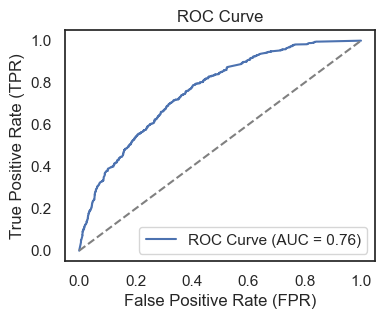

In [80]:

RF2 = RandomForestClassifier(random_state=42)
RF2.fit(x_train_sc, y_train)  

y_prob = RF2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### KNeighborsClassifier

In [81]:
from sklearn.neighbors import KNeighborsClassifier
KNC=KNeighborsClassifier()
KNC.fit(x_sm,y_sm)
y_predict=KNC.predict(x_test_sc)
y_pre_train=KNC.predict(x_sm)

In [82]:
acc_knc=accuracy_score(y_test,y_predict)
recall_knc=recall_score(y_test,y_predict,pos_label=1)
prec_knc=precision_score(y_test,y_predict,pos_label=1)
f1_knc=f1_score(y_test,y_predict,pos_label=1)
cl_knc=classification_report(y_test,y_predict)
cm_knc=confusion_matrix(y_test,y_predict)

print(f"KNeighbors TEST score:")
print(f"KNeighbors Accuracy score:{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
pd.crosstab(y_test,y_predict)

KNeighbors TEST score:
KNeighbors Accuracy score:0.6477445514445007
KNeighbors Recall score:0.6538024971623155
KNeighbors Precision score:0.5962732919254659
KNeighbors F1 score:0.623714131023281
              precision    recall  f1-score   support

           0       0.70      0.64      0.67      1092
           1       0.60      0.65      0.62       881

    accuracy                           0.65      1973
   macro avg       0.65      0.65      0.65      1973
weighted avg       0.65      0.65      0.65      1973

KNeighbors Confusion Matrix:[[702 390]
 [305 576]]


col_0,0,1
Status,,
0,702,390
1,305,576


In [83]:
acc_knc=accuracy_score(y_sm,y_pre_train)
recall_knc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_knc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_knc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_knc=classification_report(y_sm,y_pre_train)
cm_knc=confusion_matrix(y_sm,y_pre_train)

print(f"KNeighbors TRAIN score:")
print(f"KNeighbors Accuracy score:{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
pd.crosstab(y_sm,y_pre_train)

KNeighbors TRAIN score:
KNeighbors Accuracy score:0.7798861480075902
KNeighbors Recall score:0.815180265654649
KNeighbors Precision score:0.761432116270826
KNeighbors F1 score:0.7873900293255132
              precision    recall  f1-score   support

           0       0.80      0.74      0.77      2635
           1       0.76      0.82      0.79      2635

    accuracy                           0.78      5270
   macro avg       0.78      0.78      0.78      5270
weighted avg       0.78      0.78      0.78      5270

KNeighbors Confusion Matrix:[[1962  673]
 [ 487 2148]]


col_0,0,1
Status,,
0,1962,673
1,487,2148


In [84]:
# Define the parameter grid
params = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}
neighbors_clf = KNeighborsClassifier()
neighbors_cv = GridSearchCV(neighbors_clf, params, scoring='accuracy', n_jobs=-1, cv=5)

neighbors_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = neighbors_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'metric': 'euclidean', 'n_neighbors': 10, 'p': 1, 'weights': 'uniform'})


In [85]:
KNC1= KNeighborsClassifier(metric='euclidean',n_neighbors=10,p=1,weights='uniform')

In [86]:
KNC1.fit(x_sm,y_sm)
y_predict=KNC1.predict(x_test_sc)
y_pre_train=KNC1.predict(x_sm)

In [87]:
acc_knc=accuracy_score(y_test,y_predict)
recall_knc=recall_score(y_test,y_predict,pos_label=1)
prec_knc=precision_score(y_test,y_predict,pos_label=1)
f1_knc=f1_score(y_test,y_predict,pos_label=1)
cl_knc=classification_report(y_test,y_predict)
cm_knc=confusion_matrix(y_test,y_predict)

print(f"KNeighbors TEST score after HP Tuning:")
print(f"KNeighbors Accuracy score after :{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
pd.crosstab(y_test,y_predict)

KNeighbors TEST score after HP Tuning:
KNeighbors Accuracy score after :0.6675114039533705
KNeighbors Recall score:0.6152099886492622
KNeighbors Precision score:0.6309662398137369
KNeighbors F1 score:0.6229885057471264
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1092
           1       0.63      0.62      0.62       881

    accuracy                           0.67      1973
   macro avg       0.66      0.66      0.66      1973
weighted avg       0.67      0.67      0.67      1973

KNeighbors Confusion Matrix:[[775 317]
 [339 542]]


col_0,0,1
Status,,
0,775,317
1,339,542


In [88]:
acc_knc=accuracy_score(y_sm,y_pre_train)
recall_knc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_knc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_knc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_knc=classification_report(y_sm,y_pre_train)
cm_knc=confusion_matrix(y_sm,y_pre_train)

print(f"KNeighbors TRAIN score after HP Tuning:")
print(f"KNeighbors Accuracy score:{acc_knc}")
print(f"KNeighbors Recall score:{recall_knc}")
print(f"KNeighbors Precision score:{prec_knc}")
print(f"KNeighbors F1 score:{f1_knc}")
print(f"{cl_knc}")
print(f"KNeighbors Confusion Matrix:{cm_knc}")
pd.crosstab(y_sm,y_pre_train)

KNeighbors TRAIN score after HP Tuning:
KNeighbors Accuracy score:0.7533206831119544
KNeighbors Recall score:0.7396584440227704
KNeighbors Precision score:0.7604369879047991
KNeighbors F1 score:0.7499038091573682
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      2635
           1       0.76      0.74      0.75      2635

    accuracy                           0.75      5270
   macro avg       0.75      0.75      0.75      5270
weighted avg       0.75      0.75      0.75      5270

KNeighbors Confusion Matrix:[[2021  614]
 [ 686 1949]]


col_0,0,1
Status,,
0,2021,614
1,686,1949


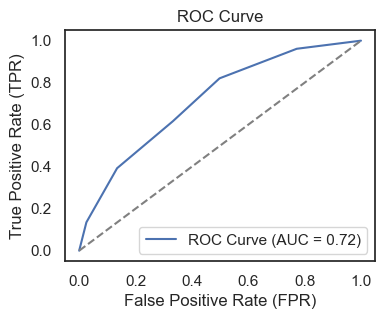

In [89]:

KNC2 = KNeighborsClassifier()
KNC2.fit(x_train_sc, y_train)  

y_prob = KNC2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### GradientBoostingClassifier

In [90]:
from sklearn.ensemble import GradientBoostingClassifier
GBC=GradientBoostingClassifier()
GBC.fit(x_sm,y_sm)
y_predict=GBC.predict(x_test_sc)
y_pre_train=GBC.predict(x_sm)

In [91]:
acc_gbc=accuracy_score(y_test,y_predict)
recall_gbc=recall_score(y_test,y_predict,pos_label=1)
prec_gbc=precision_score(y_test,y_predict,pos_label=1)
f1_gbc=f1_score(y_test,y_predict,pos_label=1)
cl_gbc=classification_report(y_test,y_predict)
cm_gbc=confusion_matrix(y_test,y_predict)

print(f"GradientBoostingClassifier TEST score:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
pd.crosstab(y_test,y_predict)

GradientBoostingClassifier TEST score:
GradientBoostingClassifier Accuracy score:0.7146477445514445
GradientBoostingClassifier Recall score:0.7321225879682179
GradientBoostingClassifier Precision score:0.6635802469135802
GradientBoostingClassifier F1 score:0.6961683756071236
              precision    recall  f1-score   support

           0       0.76      0.70      0.73      1092
           1       0.66      0.73      0.70       881

    accuracy                           0.71      1973
   macro avg       0.71      0.72      0.71      1973
weighted avg       0.72      0.71      0.72      1973

GradientBoostingClassifier Confusion Matrix:[[765 327]
 [236 645]]


col_0,0,1
Status,,
0,765,327
1,236,645


In [92]:
acc_gbc=accuracy_score(y_sm,y_pre_train)
recall_gbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_gbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_gbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_gbc=classification_report(y_sm,y_pre_train)
cm_gbc=confusion_matrix(y_sm,y_pre_train)

print(f"GradientBoostingClassifier TRAIN score:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
pd.crosstab(y_sm,y_pre_train)

GradientBoostingClassifier TRAIN score:
GradientBoostingClassifier Accuracy score:0.7571157495256167
GradientBoostingClassifier Recall score:0.8007590132827325
GradientBoostingClassifier Precision score:0.7364746945898778
GradientBoostingClassifier F1 score:0.7672727272727272
              precision    recall  f1-score   support

           0       0.78      0.71      0.75      2635
           1       0.74      0.80      0.77      2635

    accuracy                           0.76      5270
   macro avg       0.76      0.76      0.76      5270
weighted avg       0.76      0.76      0.76      5270

GradientBoostingClassifier Confusion Matrix:[[1880  755]
 [ 525 2110]]


col_0,0,1
Status,,
0,1880,755
1,525,2110


In [93]:
params = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}
boosting_clf = GradientBoostingClassifier()
boosting_cv = RandomizedSearchCV(boosting_clf, params, n_iter=20, scoring='accuracy', n_jobs=-1, cv=5, random_state=42)

boosting_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = boosting_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.2})


In [94]:
GBC1= GradientBoostingClassifier(learning_rate=0.2,max_depth=3,min_samples_leaf=1,min_samples_split=5,n_estimators=200,subsample=1.0)

In [95]:
GBC1.fit(x_sm,y_sm)
y_predict=GBC1.predict(x_test_sc)
y_pre_train=GBC1.predict(x_sm)

In [96]:
acc_gbc=accuracy_score(y_test,y_predict)
recall_gbc=recall_score(y_test,y_predict,pos_label=1)
prec_gbc=precision_score(y_test,y_predict,pos_label=1)
f1_gbc=f1_score(y_test,y_predict,pos_label=1)
cl_gbc=classification_report(y_test,y_predict)
cm_gbc=confusion_matrix(y_test,y_predict)

print(f"GradientBoostingClassifier TEST score after HP Tuning:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
pd.crosstab(y_test,y_predict)

GradientBoostingClassifier TEST score after HP Tuning:
GradientBoostingClassifier Accuracy score:0.7085656360871769
GradientBoostingClassifier Recall score:0.6878547105561862
GradientBoostingClassifier Precision score:0.6688741721854304
GradientBoostingClassifier F1 score:0.6782316731952994
              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1092
           1       0.67      0.69      0.68       881

    accuracy                           0.71      1973
   macro avg       0.71      0.71      0.71      1973
weighted avg       0.71      0.71      0.71      1973

GradientBoostingClassifier Confusion Matrix:[[792 300]
 [275 606]]


col_0,0,1
Status,,
0,792,300
1,275,606


In [97]:
acc_gbc=accuracy_score(y_sm,y_pre_train)
recall_gbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_gbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_gbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_gbc=classification_report(y_sm,y_pre_train)
cm_gbc=confusion_matrix(y_sm,y_pre_train)

print(f"GradientBoostingClassifier TRAIN score after HP Tuning:")
print(f"GradientBoostingClassifier Accuracy score:{acc_gbc}")
print(f"GradientBoostingClassifier Recall score:{recall_gbc}")
print(f"GradientBoostingClassifier Precision score:{prec_gbc}")
print(f"GradientBoostingClassifier F1 score:{f1_gbc}")
print(f"{cl_gbc}")
print(f"GradientBoostingClassifier Confusion Matrix:{cm_gbc}")
pd.crosstab(y_sm,y_pre_train)

GradientBoostingClassifier TRAIN score after HP Tuning:
GradientBoostingClassifier Accuracy score:0.789753320683112
GradientBoostingClassifier Recall score:0.8003795066413663
GradientBoostingClassifier Precision score:0.7837235228539576
GradientBoostingClassifier F1 score:0.7919639504318438
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2635
           1       0.78      0.80      0.79      2635

    accuracy                           0.79      5270
   macro avg       0.79      0.79      0.79      5270
weighted avg       0.79      0.79      0.79      5270

GradientBoostingClassifier Confusion Matrix:[[2053  582]
 [ 526 2109]]


col_0,0,1
Status,,
0,2053,582
1,526,2109


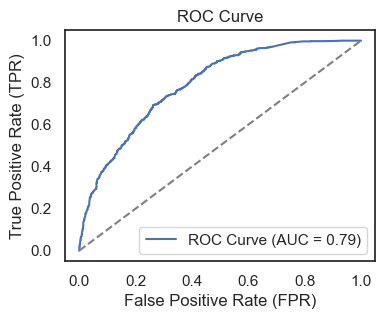

In [98]:

GBC2 = GradientBoostingClassifier()
GBC2.fit(x_train_sc, y_train)  

y_prob = GBC2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### XGBClassifier

In [99]:
from xgboost import XGBClassifier
XGBC=XGBClassifier(use_label_encoder=False)
XGBC.fit(x_sm,y_sm)
y_predict=XGBC.predict(x_test_sc)
y_pre_train=XGBC.predict(x_sm)

In [100]:
acc_xgbc=accuracy_score(y_test,y_predict)
recall_xgbc=recall_score(y_test,y_predict,pos_label=1)
prec_xgbc=precision_score(y_test,y_predict,pos_label=1)
f1_xgbc=f1_score(y_test,y_predict,pos_label=1)
cl_xgbc=classification_report(y_test,y_predict)
cm_xgbc=confusion_matrix(y_test,y_predict)

print(f"XGBClassifier TEST score:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
pd.crosstab(y_test,y_predict)

XGBClassifier TEST score:
XGBClassifier Accuracy score:0.6953877344145971
XGBClassifier Recall score:0.6685584562996595
XGBClassifier Precision score:0.655902004454343
XGBClassifier F1 score:0.6621697582911749
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      1092
           1       0.66      0.67      0.66       881

    accuracy                           0.70      1973
   macro avg       0.69      0.69      0.69      1973
weighted avg       0.70      0.70      0.70      1973

XGBClassifier Confusion Matrix:[[783 309]
 [292 589]]


col_0,0,1
Status,,
0,783,309
1,292,589


In [101]:
acc_xgbc=accuracy_score(y_sm,y_pre_train)
recall_xgbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_xgbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_xgbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_xgbc=classification_report(y_sm,y_pre_train)
cm_xgbc=confusion_matrix(y_sm,y_pre_train)

print(f"XGBClassifier TRAIN score:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
pd.crosstab(y_sm,y_pre_train)

XGBClassifier TRAIN score:
XGBClassifier Accuracy score:0.8356736242884251
XGBClassifier Recall score:0.8550284629981024
XGBClassifier Precision score:0.8231640482279868
XGBClassifier F1 score:0.8387937453462397
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      2635
           1       0.82      0.86      0.84      2635

    accuracy                           0.84      5270
   macro avg       0.84      0.84      0.84      5270
weighted avg       0.84      0.84      0.84      5270

XGBClassifier Confusion Matrix:[[2151  484]
 [ 382 2253]]


col_0,0,1
Status,,
0,2151,484
1,382,2253


In [102]:
from skopt.space import Real, Integer, Categorical

params = {
    'n_estimators': Integer(100, 500),               # Number of trees
    'learning_rate': Real(0.01, 0.1),                # Learning rate
    'max_depth': Integer(3, 7),                      # Max depth of trees
    'min_child_weight': Integer(1, 5),               # Minimum child weight
    'subsample': Real(0.7, 1.0),                     # Subsample ratio of the training data
    'colsample_bytree': Real(0.7, 1.0),              # Subsample ratio of columns when constructing each tree
    'gamma': Real(0.0, 0.5),                         # Minimum loss reduction required to make a further partition
}
Xboosting_clf = XGBClassifier(use_label_encoder=False)
Xboosting_cv = BayesSearchCV(Xboosting_clf,params,n_iter=50,scoring='accuracy',n_jobs=-1,cv=5,random_state=42)

Xboosting_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = Xboosting_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: OrderedDict([('colsample_bytree', 0.9512165066659852), ('gamma', 0.4416576386904311), ('learning_rate', 0.03730690988957575), ('max_depth', 7), ('min_child_weight', 4), ('n_estimators', 125), ('subsample', 0.7414925614835726)]))


In [103]:
XGBC1=XGBClassifier(colsample_bytree=0.9512165066659852,gamma=0.4416576386904311,learning_rate=0.03730690988957575,max_depth=7,min_child_weight=4,n_estimators=125,subsample=0.7414925614835726)

In [104]:
XGBC1.fit(x_sm,y_sm)
y_predict=XGBC1.predict(x_test_sc)
y_pre_train=XGBC1.predict(x_sm)

In [105]:
acc_xgbc=accuracy_score(y_test,y_predict)
recall_xgbc=recall_score(y_test,y_predict,pos_label=1)
prec_xgbc=precision_score(y_test,y_predict,pos_label=1)
f1_xgbc=f1_score(y_test,y_predict,pos_label=1)
cl_xgbc=classification_report(y_test,y_predict)
cm_xgbc=confusion_matrix(y_test,y_predict)

print(f"XGBClassifier TEST score after HP Tuning:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
pd.crosstab(y_test,y_predict)

XGBClassifier TEST score after HP Tuning:
XGBClassifier Accuracy score:0.7014698428788647
XGBClassifier Recall score:0.7060158910329172
XGBClassifier Precision score:0.6533613445378151
XGBClassifier F1 score:0.6786688488816148
              precision    recall  f1-score   support

           0       0.75      0.70      0.72      1092
           1       0.65      0.71      0.68       881

    accuracy                           0.70      1973
   macro avg       0.70      0.70      0.70      1973
weighted avg       0.70      0.70      0.70      1973

XGBClassifier Confusion Matrix:[[762 330]
 [259 622]]


col_0,0,1
Status,,
0,762,330
1,259,622


In [106]:
acc_xgbc=accuracy_score(y_sm,y_pre_train)
recall_xgbc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_xgbc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_xgbc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_xgbc=classification_report(y_sm,y_pre_train)
cm_xgbc=confusion_matrix(y_sm,y_pre_train)

print(f"XGBClassifier TRAIN score:")
print(f"XGBClassifier Accuracy score:{acc_xgbc}")
print(f"XGBClassifier Recall score:{recall_xgbc}")
print(f"XGBClassifier Precision score:{prec_xgbc}")
print(f"XGBClassifier F1 score:{f1_xgbc}")
print(f"{cl_xgbc}")
print(f"XGBClassifier Confusion Matrix:{cm_xgbc}")
pd.crosstab(y_sm,y_pre_train)

XGBClassifier TRAIN score:
XGBClassifier Accuracy score:0.7941176470588235
XGBClassifier Recall score:0.8277039848197344
XGBClassifier Precision score:0.7756045519203414
XGBClassifier F1 score:0.8008077841013402
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      2635
           1       0.78      0.83      0.80      2635

    accuracy                           0.79      5270
   macro avg       0.80      0.79      0.79      5270
weighted avg       0.80      0.79      0.79      5270

XGBClassifier Confusion Matrix:[[2004  631]
 [ 454 2181]]


col_0,0,1
Status,,
0,2004,631
1,454,2181


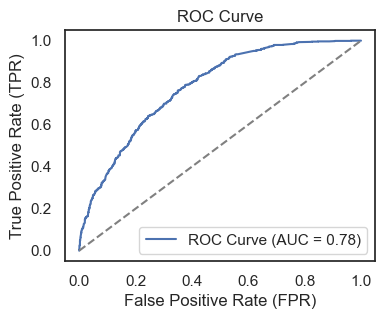

In [107]:

XGBC2 = XGBClassifier()
XGBC2.fit(x_train_sc, y_train)  

y_prob = XGBC2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### RadiusNeighborsClassifier

In [108]:
from sklearn.neighbors import RadiusNeighborsClassifier
RNC=RadiusNeighborsClassifier(radius=2.0, weights='distance', metric='minkowski', p=2)
RNC.fit(x_sm,y_sm)
y_predict=RNC.predict(x_test_sc)
y_pre_train=RNC.predict(x_sm)

In [109]:
acc_rnc=accuracy_score(y_test,y_predict)
recall_rnc=recall_score(y_test,y_predict,pos_label=1)
prec_rnc=precision_score(y_test,y_predict,pos_label=1)
f1_rnc=f1_score(y_test,y_predict,pos_label=1)
cl_rnc=classification_report(y_test,y_predict)
cm_rnc=confusion_matrix(y_test,y_predict)

print(f"RadiusNeighborsClassifier TEST score:")
print(f"RadiusNeighborsClassifier Accuracy score:{acc_rnc}")
print(f"RadiusNeighborsClassifier Recall score:{recall_rnc}")
print(f"RadiusNeighborsClassifier Precision score:{prec_rnc}")
print(f"RadiusNeighborsClassifier F1 score:{f1_rnc}")
print(f"{cl_rnc}")
print(f"RadiusNeighborsClassifier Confusion Matrix:{cm_rnc}")
pd.crosstab(y_test,y_predict)

RadiusNeighborsClassifier TEST score:
RadiusNeighborsClassifier Accuracy score:0.6528129751647238
RadiusNeighborsClassifier Recall score:0.6129398410896708
RadiusNeighborsClassifier Precision score:0.6108597285067874
RadiusNeighborsClassifier F1 score:0.6118980169971672
              precision    recall  f1-score   support

           0       0.69      0.68      0.69      1092
           1       0.61      0.61      0.61       881

    accuracy                           0.65      1973
   macro avg       0.65      0.65      0.65      1973
weighted avg       0.65      0.65      0.65      1973

RadiusNeighborsClassifier Confusion Matrix:[[748 344]
 [341 540]]


col_0,0,1
Status,,
0,748,344
1,341,540


In [110]:
acc_rnc=accuracy_score(y_sm,y_pre_train)
recall_rnc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rnc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rnc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rnc=classification_report(y_sm,y_pre_train)
cm_rnc=confusion_matrix(y_sm,y_pre_train)

print(f"RadiusNeighborsClassifier TRAIN score:")
print(f"RadiusNeighborsClassifier Accuracy score:{acc_rnc}")
print(f"RadiusNeighborsClassifier Recall score:{recall_rnc}")
print(f"RadiusNeighborsClassifier Precision score:{prec_rnc}")
print(f"RadiusNeighborsClassifier F1 score:{f1_rnc}")
print(f"{cl_rnc}")
print(f"RadiusNeighborsClassifier Confusion Matrix:{cm_rnc}")
pd.crosstab(y_sm,y_pre_train)

RadiusNeighborsClassifier TRAIN score:
RadiusNeighborsClassifier Accuracy score:0.8850094876660342
RadiusNeighborsClassifier Recall score:0.8535104364326376
RadiusNeighborsClassifier Precision score:0.9108950992304576
RadiusNeighborsClassifier F1 score:0.8812695924764891
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      2635
           1       0.91      0.85      0.88      2635

    accuracy                           0.89      5270
   macro avg       0.89      0.89      0.88      5270
weighted avg       0.89      0.89      0.88      5270

RadiusNeighborsClassifier Confusion Matrix:[[2415  220]
 [ 386 2249]]


col_0,0,1
Status,,
0,2415,220
1,386,2249


In [111]:
params = {
    'radius': [1.0, 2.0, 3.0],  # Test different radii
    'weights': ['uniform', 'distance'],  # Uniform or distance-based weights
    'metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metrics
    'p': [1, 2],  # Power parameter for Minkowski
    'outlier_label': [0, 1]  # Handle outliers by assigning class 0 or 1
}
rnc_clf =RadiusNeighborsClassifier()
rnc_cv =  GridSearchCV(rnc_clf, params, scoring='accuracy', n_jobs=-1, cv=5)

rnc_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = rnc_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Best paramters: {'metric': 'euclidean', 'outlier_label': 0, 'p': 1, 'radius': 1.0, 'weights': 'uniform'})


In [112]:
RNC1 = RadiusNeighborsClassifier(metric='euclidean', outlier_label=0, p=1, radius=1.0, weights='uniform')

In [113]:
RNC1.fit(x_sm,y_sm)
y_predict=RNC1.predict(x_test_sc)
y_pre_train=RNC1.predict(x_sm)

In [114]:
acc_rnc=accuracy_score(y_test,y_predict)
recall_rnc=recall_score(y_test,y_predict,pos_label=1)
prec_rnc=precision_score(y_test,y_predict,pos_label=1)
f1_rnc=f1_score(y_test,y_predict,pos_label=1)
cl_rnc=classification_report(y_test,y_predict)
cm_rnc=confusion_matrix(y_test,y_predict)

print(f"RadiusNeighborsClassifier TEST score after HP Tuning:")
print(f"RadiusNeighborsClassifier Accuracy score:{acc_rnc}")
print(f"RadiusNeighborsClassifier Recall score:{recall_rnc}")
print(f"RadiusNeighborsClassifier Precision score:{prec_rnc}")
print(f"RadiusNeighborsClassifier F1 score:{f1_rnc}")
print(f"{cl_rnc}")
print(f"RadiusNeighborsClassifier Confusion Matrix:{cm_rnc}")
pd.crosstab(y_test,y_predict)

RadiusNeighborsClassifier TEST score after HP Tuning:
RadiusNeighborsClassifier Accuracy score:0.6538266599087684
RadiusNeighborsClassifier Recall score:0.695800227014756
RadiusNeighborsClassifier Precision score:0.5963035019455253
RadiusNeighborsClassifier F1 score:0.642221058145626
              precision    recall  f1-score   support

           0       0.72      0.62      0.66      1092
           1       0.60      0.70      0.64       881

    accuracy                           0.65      1973
   macro avg       0.66      0.66      0.65      1973
weighted avg       0.66      0.65      0.65      1973

RadiusNeighborsClassifier Confusion Matrix:[[677 415]
 [268 613]]


col_0,0,1
Status,,
0,677,415
1,268,613


In [115]:
acc_rnc=accuracy_score(y_sm,y_pre_train)
recall_rnc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_rnc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_rnc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_rnc=classification_report(y_sm,y_pre_train)
cm_rnc=confusion_matrix(y_sm,y_pre_train)

print(f"RadiusNeighborsClassifier TRAIN score:")
print(f"RadiusNeighborsClassifier Accuracy score:{acc_rnc}")
print(f"RadiusNeighborsClassifier Recall score:{recall_rnc}")
print(f"RadiusNeighborsClassifier Precision score:{prec_rnc}")
print(f"RadiusNeighborsClassifier F1 score:{f1_rnc}")
print(f"{cl_rnc}")
print(f"RadiusNeighborsClassifier Confusion Matrix:{cm_rnc}")
pd.crosstab(y_sm,y_pre_train)

RadiusNeighborsClassifier TRAIN score:
RadiusNeighborsClassifier Accuracy score:0.7001897533206831
RadiusNeighborsClassifier Recall score:0.752561669829222
RadiusNeighborsClassifier Precision score:0.6812092064582618
RadiusNeighborsClassifier F1 score:0.715109989181392
              precision    recall  f1-score   support

           0       0.72      0.65      0.68      2635
           1       0.68      0.75      0.72      2635

    accuracy                           0.70      5270
   macro avg       0.70      0.70      0.70      5270
weighted avg       0.70      0.70      0.70      5270

RadiusNeighborsClassifier Confusion Matrix:[[1707  928]
 [ 652 1983]]


col_0,0,1
Status,,
0,1707,928
1,652,1983


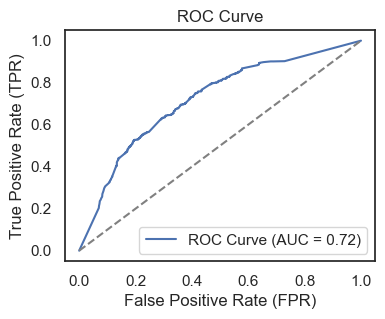

In [116]:

RNC2 = RadiusNeighborsClassifier(radius=2.0, weights='distance', metric='minkowski', p=2)
RNC2.fit(x_train_sc, y_train)  

y_prob = RNC2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


#### LGBMClassifier

In [117]:
from lightgbm import LGBMClassifier
LGBMC = LGBMClassifier(random_state=42)
LGBMC.fit(x_sm,y_sm)
y_predict=LGBMC.predict(x_test_sc)
y_pre_train=LGBMC.predict(x_sm) 

[LightGBM] [Info] Number of positive: 2635, number of negative: 2635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 5270, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [118]:
acc_lgbmc=accuracy_score(y_test,y_predict)
recall_lgbmc=recall_score(y_test,y_predict,pos_label=1)
prec_lgbmc=precision_score(y_test,y_predict,pos_label=1)
f1_lgbmc=f1_score(y_test,y_predict,pos_label=1)
cl_lgbmc=classification_report(y_test,y_predict)
cm_lgbmc=confusion_matrix(y_test,y_predict)

print(f"LGBMClassifier TEST score:")
print(f"LGBMClassifier Accuracy score:{acc_lgbmc}")
print(f"LGBMClassifier Recall score:{recall_lgbmc}")
print(f"LGBMClassifier Precision score:{prec_lgbmc}")
print(f"LGBMClassifier F1 score:{f1_lgbmc}")
print(f"{cl_lgbmc}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbmc}")
pd.crosstab(y_test,y_predict)

LGBMClassifier TEST score:
LGBMClassifier Accuracy score:0.7004561581348201
LGBMClassifier Recall score:0.6696935300794552
LGBMClassifier Precision score:0.6629213483146067
LGBMClassifier F1 score:0.6662902315076228
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1092
           1       0.66      0.67      0.67       881

    accuracy                           0.70      1973
   macro avg       0.70      0.70      0.70      1973
weighted avg       0.70      0.70      0.70      1973

LGBMClassifier Confusion Matrix:[[792 300]
 [291 590]]


col_0,0,1
Status,,
0,792,300
1,291,590


In [119]:
acc_lgbmc=accuracy_score(y_sm,y_pre_train)
recall_lgbmc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lgbmc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lgbmc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lgbmc=classification_report(y_sm,y_pre_train)
cm_lgbmc=confusion_matrix(y_sm,y_pre_train)

print(f"LGBMClassifier TRAIN score:")
print(f"LGBMClassifier Accuracy score:{acc_lgbmc}")
print(f"LGBMClassifier Recall score:{recall_lgbmc}")
print(f"LGBMClassifier Precision score:{prec_lgbmc}")
print(f"LGBMClassifier F1 score:{f1_lgbmc}")
print(f"{cl_lgbmc}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbmc}")
pd.crosstab(y_sm,y_pre_train)

LGBMClassifier TRAIN score:
LGBMClassifier Accuracy score:0.8142314990512334
LGBMClassifier Recall score:0.8333965844402277
LGBMClassifier Precision score:0.8026315789473685
LGBMClassifier F1 score:0.8177248184695587
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      2635
           1       0.80      0.83      0.82      2635

    accuracy                           0.81      5270
   macro avg       0.81      0.81      0.81      5270
weighted avg       0.81      0.81      0.81      5270

LGBMClassifier Confusion Matrix:[[2095  540]
 [ 439 2196]]


col_0,0,1
Status,,
0,2095,540
1,439,2196


In [122]:
params = {
    'n_estimators': [100, 200, 500],
    'num_leaves': [20, 31, 40, 50],  # Controls the complexity of the tree
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [ 10, 20, 30], 
    'min_child_samples': [20, 30, 50],  # Minimum number of data needed in a child
    'subsample': [0.7, 0.8, 1.0],  # Fraction of data to be used for training
    'colsample_bytree': [0.7, 0.8, 1.0],  # Fraction of features to be used for each tree
    'reg_alpha': [0, 0.01, 0.1, 0.5],  # L1 regularization
    'reg_lambda': [0, 0.01, 0.1, 0.5],  # L2 regularization
}
lgbm_c =LGBMClassifier( random_state=42)
lgbm_c = RandomizedSearchCV(lgbm_c, params, n_iter=50, scoring='accuracy', verbose=1, cv=5, n_jobs=-1, random_state=42)

lgbm_c.fit(x_train,y_train)
best_params = lgbm_c.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Number of positive: 1966, number of negative: 2635
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76
[LightGBM] [Info] Number of data points in the train set: 4601, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.427298 -> initscore=-0.292882
[LightGBM] [Info] Start training from score -0.292882
Best paramters: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 40, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7})


In [123]:
LGBMC1 = LGBMClassifier(subsample=0.8, reg_lambda=0.1, reg_alpha=0.1, num_leaves=40, n_estimators=100, min_child_samples=20, max_depth=10, learning_rate=0.05, colsample_bytree=0.7)

In [124]:
LGBMC1.fit(x_sm,y_sm)
y_predict=LGBMC1.predict(x_test_sc)
y_pre_train=LGBMC1.predict(x_sm)

[LightGBM] [Info] Number of positive: 2635, number of negative: 2635
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000348 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 5270, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [125]:
acc_lgbmc=accuracy_score(y_test,y_predict)
recall_lgbmc=recall_score(y_test,y_predict,pos_label=1)
prec_lgbmc=precision_score(y_test,y_predict,pos_label=1)
f1_lgbmc=f1_score(y_test,y_predict,pos_label=1)
cl_lgbmc=classification_report(y_test,y_predict)
cm_lgbmc=confusion_matrix(y_test,y_predict)

print(f"LGBMClassifier TEST score after HP Tuning:")
print(f"LGBMClassifier Accuracy score:{acc_lgbmc}")
print(f"LGBMClassifier Recall score:{recall_lgbmc}")
print(f"LGBMClassifier Precision score:{prec_lgbmc}")
print(f"LGBMClassifier F1 score:{f1_lgbmc}")
print(f"{cl_lgbmc}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbmc}")
pd.crosstab(y_test,y_predict)

LGBMClassifier TEST score after HP Tuning:
LGBMClassifier Accuracy score:0.7009630005068423
LGBMClassifier Recall score:0.6821793416572077
LGBMClassifier Precision score:0.6597145993413831
LGBMClassifier F1 score:0.6707589285714286
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      1092
           1       0.66      0.68      0.67       881

    accuracy                           0.70      1973
   macro avg       0.70      0.70      0.70      1973
weighted avg       0.70      0.70      0.70      1973

LGBMClassifier Confusion Matrix:[[782 310]
 [280 601]]


col_0,0,1
Status,,
0,782,310
1,280,601


In [126]:
acc_lgbmc=accuracy_score(y_sm,y_pre_train)
recall_lgbmc=recall_score(y_sm,y_pre_train,pos_label=1)
prec_lgbmc=precision_score(y_sm,y_pre_train,pos_label=1)
f1_lgbmc=f1_score(y_sm,y_pre_train,pos_label=1)
cl_lgbmc=classification_report(y_sm,y_pre_train)
cm_lgbmc=confusion_matrix(y_sm,y_pre_train)

print(f"LGBMClassifier TRAIN score after HP Tuning:")
print(f"LGBMClassifier Accuracy score:{acc_lgbmc}")
print(f"LGBMClassifier Recall score:{recall_lgbmc}")
print(f"LGBMClassifier Precision score:{prec_lgbmc}")
print(f"LGBMClassifier F1 score:{f1_lgbmc}")
print(f"{cl_lgbmc}")
print(f"LGBMClassifier Confusion Matrix:{cm_lgbmc}")
pd.crosstab(y_sm,y_pre_train)

LGBMClassifier TRAIN score after HP Tuning:
LGBMClassifier Accuracy score:0.7988614800759013
LGBMClassifier Recall score:0.8314990512333966
LGBMClassifier Precision score:0.7805486284289277
LGBMClassifier F1 score:0.8052186696067622
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      2635
           1       0.78      0.83      0.81      2635

    accuracy                           0.80      5270
   macro avg       0.80      0.80      0.80      5270
weighted avg       0.80      0.80      0.80      5270

LGBMClassifier Confusion Matrix:[[2019  616]
 [ 444 2191]]


col_0,0,1
Status,,
0,2019,616
1,444,2191


[LightGBM] [Info] Number of positive: 1966, number of negative: 2635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 80
[LightGBM] [Info] Number of data points in the train set: 4601, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.427298 -> initscore=-0.292882
[LightGBM] [Info] Start training from score -0.292882


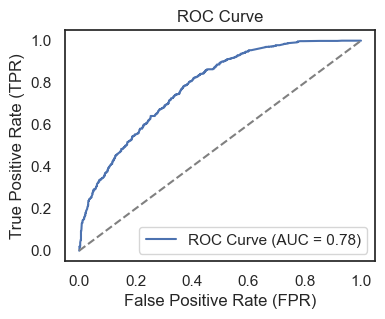

In [127]:

LGBMC2 = LGBMClassifier(random_state=42)
LGBMC2.fit(x_train_sc, y_train)  

y_prob = LGBMC2.predict_proba(x_test_sc)[:, 1]  # Get the probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## Report on Challenges faced and Model Comparison

The objective of this project is to develop a predictive model that accurately classifies leads as either "High Potential" or "Low Potential" based on historical sales data. This model aims to assist the sales team in prioritizing their efforts by identifying high-potential leads, enabling more effective resource allocation and improving overall conversion rates. Additionally, the project will provide actionable insights into sales effectiveness, helping to optimize lead generation strategies and enhance sales performance.

 # Challenges Faced:
1) **Class Imbalance**:- The dataset likely had an imbalance between high-potential and low-potential leads. This imbalance can cause models to perform poorly on the minority class (high-potential leads) by favoring the majority class (low-potential leads).
2) **Handling Categorical Features**:- Categorical columns like Source, Sales_Agent, and Location needed to be transformed into numerical form using encoding techniques to be effectively used by machine learning algorithms.
3) **High Dimensionality**:- The dataset contained several features, including some that might not contribute much to the model’s performance. Identifying and selecting the most important features was a challenge to prevent dimensionality issues and overfitting.
4) **Hyperparameter Tuning Complexity**:-Optimizing hyperparameters for complex models like Random Forest, XGBoost, and Gradient Boosting required substantial computational resources and time due to the large search space of potential hyperparameters.
5) **Model Performance Variations**:- Different models such as Logistic Regression, Decision Tree, Random Forest, and XGBoost exhibited varying performances, which made it challenging to select a model that performed well across all key metrics (accuracy, precision, recall, F1-score, AUC).
6) **Overfitting on Training Data**:- More complex models like XGBoost and Random Forest tended to overfit the training data, making it difficult to generalize to unseen test data.
7) **Time and Resource Constraints**:- Training and hyperparameter tuning for models like Support Vector Classifier (SVC) was time-consuming and resource-intensive, leading to the decision to avoid using it in favor of more efficient algorithms or simpler models for deployment.

 # Techniques Used:
1) **Class Imbalance Handling**:- **SMOTE** (Synthetic Minority Over-sampling Technique) was applied to balance the dataset and improve model performance on the minority class (high-potential leads).
2) **Label Encoding for Categorical Variables**:- Categorical columns like Source, Sales_Agent, and Location were converted into numerical format using Label Encoding.
3) **Feature Selection**:- Feature importance techniques and correlation analysis were used to identify and select the most relevant features, ensuring the model focused on the most impactful variables.
4) **Cross-Validation**:- Cross-validation was used to assess model performance across different folds of the data, ensuring that the models did not overfit the training data and could generalize well.
5) **Hyperparameter Tuning**:- Hyperparameter tuning was performed using GridSearchCV, RandomizedSearchCV, and BayesSearchCV to find the optimal hyperparameters.
6) **Standardization and Scaling**:- StandardScaler was used to standardize numerical features ensuring consistent scales across features for models.
7) **Model Evaluation Metrics**:- Models were evaluated using multiple metrics like Accuracy, Precision, Recall, F1-Score, and AUC, ensuring a balanced evaluation of model performance.



### Comparing TEST scores of different models after Hyperparameter Tuning:

In [130]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Model", "Accuracy", "Recall", "Precision", "F1 Score", "AUC Score"]

table.add_row(["Logistic Regression", "0.6599", "0.7151", "0.6000", "0.6525", "0.71"])
table.add_row(["Decision Tree", "0.6705", "0.6140", "0.6357", "0.6247", "0.68"])
table.add_row(["Random Forest", "0.7034", "0.7412", "0.6465", "0.6906", "0.76"])
table.add_row(["K-Neighbors", "0.6675", "0.6152", "0.6309", "0.6229", "0.72"])
table.add_row(["Gradient Boosting", "0.7085", "0.6878", "0.6688", "0.6782", "0.79"])
table.add_row(["XGBoost", "0.7014", "0.7060", "0.6533", "0.6786", "0.78"])
table.add_row(["Radius Neighbors", "0.6538", "0.6958", "0.5963", "0.6422", "0.72"])
table.add_row(["LightGBM", "0.7009", "0.6821", "0.6597", "0.6707", "0.78"])

print(table)


+---------------------+----------+--------+-----------+----------+-----------+
|        Model        | Accuracy | Recall | Precision | F1 Score | AUC Score |
+---------------------+----------+--------+-----------+----------+-----------+
| Logistic Regression |  0.6599  | 0.7151 |   0.6000  |  0.6525  |    0.71   |
|    Decision Tree    |  0.6705  | 0.6140 |   0.6357  |  0.6247  |    0.68   |
|    Random Forest    |  0.7034  | 0.7412 |   0.6465  |  0.6906  |    0.76   |
|     K-Neighbors     |  0.6675  | 0.6152 |   0.6309  |  0.6229  |    0.72   |
|  Gradient Boosting  |  0.7085  | 0.6878 |   0.6688  |  0.6782  |    0.79   |
|       XGBoost       |  0.7014  | 0.7060 |   0.6533  |  0.6786  |    0.78   |
|   Radius Neighbors  |  0.6538  | 0.6958 |   0.5963  |  0.6422  |    0.72   |
|       LightGBM      |  0.7009  | 0.6821 |   0.6597  |  0.6707  |    0.78   |
+---------------------+----------+--------+-----------+----------+-----------+



 #### Performance Overview:-
* Accuracy:-  Gradient Boosting and LightGBM exhibit strong accuracy scores (0.7085 and 0.7009, respectively), making them reliable for correctly predicting high-potential leads.
* Recall:- Random Forest achieves the highest recall (0.7412), indicating its effectiveness in capturing positive cases (high-potential leads). It’s ideal when the priority is identifying as many potential leads as possible, although this comes with some trade-offs in precision.
* Precision:- Gradient Boosting (0.6688) and LightGBM (0.6597) lead in precision, meaning they produce fewer false positives when predicting high-potential leads, making them more precise in their predictions.
* F1 Score:- Random Forest (0.6906) and Gradient Boosting (0.6782) show the best balance between recall and precision, offering robust performance in lead classification.
* AUC Score:- Gradient Boosting demonstrates the highest AUC score (0.79), highlighting its superior ability to distinguish between high-potential and low-potential leads, making it a top performer in terms of classification quality.

#### Based on the performance metrics, Gradient Boosting is the most suitable model for production deployment because:-
* It achieves the best balance between precision (0.6688), recall (0.6878), and F1 score (0.6782), making it highly effective in classifying high-potential leads.
* It has the highest AUC score (0.79), confirming its strong ability to differentiate between leads likely to convert and those that are not.
* Its competitive precision score (0.6688) ensures that false positives are minimized, which is critical for optimizing marketing efforts and reducing unnecessary outreach.
* Its accuracy score (0.7085) indicates that a significant portion of predictions are correct, making it reliable for overall lead classification.

#### Conclusion:-
 The main goal of this project was to predict which leads are likely to be "High Potential" based on historical data. Various machine learning models, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, Gradient Boosting, XGBoost, and LightGBM, were trained and evaluated on the dataset.

In conclusion, deploying the Gradient Boosting model will enable the sales team to more effectively identify and focus on leads with higher potential for conversion. This will help in better resource allocation, reduced marketing costs, and improved overall campaign performance, leading to more focused and successful sales efforts.

In [131]:
# creating a pickle file for Gradient Boosting model for deployment.
import pickle
with open('gradientboost_model.pkl', 'wb') as file:
    pickle.dump(GBC1, file)